# Inference Speedup Benchmark -- DINOv3 ViT-B/16

> A practical guide to every GPU inference optimization trick in PyTorch.

- toc: true
- badges: true
- comments: true
- categories: [pytorch, inference, optimization, gpu, dinov3]

How fast can we push a single forward pass of a modern vision transformer on a CUDA GPU?

Model: **DINOv3 ViT-B/16** (`dinov3_vitb16`, 86M params) --
Meta's latest self-supervised vision foundation model. A standard ViT-B
backbone with patch size 16, trained on LVD-1689M images. Heavier on
matrix multiplications than CNNs, so TF32, FP16, and SDPA/FlashAttention
deliver outsized speedups.

> **Run inside Docker for full coverage.** `torch.compile` needs Triton (Linux) and
> TensorRT EP needs `libnvinfer`. The `Dockerfile` ships both:
>
> ```bash
> docker compose up --build     # builds image, starts Jupyter on :8888
> ```
>
> On Windows (no Docker) the compile and TRT cells gracefully note what's missing.

**GPU optimizations covered:**

| # | Method | Key idea |
|---|--------|----------|
| 0 | Eager baseline | all extras disabled; clean reference point |
| 1 | `cudnn.benchmark` | auto-tune conv algorithms |
| 2 | `channels_last` | NHWC memory layout |
| 3 | `inference_mode` | stricter than `no_grad` |
| 4 | TF32 matmul | Ampere fast-math for float32 |
| 5 | AMP FP16 | autocast to half precision |
| 6 | AMP BF16 | autocast to bfloat16 |
| 7 | Static FP16 | `model.half()` permanently |
| 7b | SDPA backends | Flash / MemEfficient / Math attention |
| 8-11 | `torch.compile` | Dynamo + Inductor + Triton |
| 12 | JIT Trace + optimize | TorchScript graph fusion |
| 13 | JIT Script + optimize | full TorchScript with control-flow |
| 13b | libtorch C++ | C++ inference via the scripted model |
| 14 | Manual CUDA Graphs | replay captured kernel sequence |
| 15-16 | torchao int8 | GPU-native weight-only quantization |
| 17 | ONNX Runtime CUDA EP | ORT graph optimizations |
| 18 | ORT CUDA EP + IO Binding | zero-copy GPU inference |
| 19 | ORT TensorRT EP | TRT engine via ORT |
| 20 | ONNX int8 static quant | QDQ quantized ONNX graph |
| 21 | Torch-TensorRT | direct TRT compilation from PyTorch |
| 22 | HuggingFace Optimum | ORT via HF pipeline |
| 23 | Best combo (GPU) | compile + FP16 + CUDA Graphs + SDPA |
| 24 | Triton fused softmax | custom Triton kernel replacing attention softmax |
| 25 | compile fullgraph+freeze | zero graph breaks + Inductor tuning |
| 26-27 | Weight pruning 50% | unstructured L1 sparsity +/- compile |
| 28 | torch.export + AOTInductor | ahead-of-time compiled .so artifact |
| 29 | Multi-stream pipelining | batch splitting across CUDA streams |
| 30 | FP16 + compile reduce-overhead | the "GPT, Fast" recipe |
| 31 | torchao int4 weight-only | 4-bit weight quantization via Triton |
| 32 | **Ultimate combo** | prune 50% + FP16 + compile max-autotune + all backends |

> **New methods 24-32** inspired by [gpu-mode](https://github.com/gpu-mode) lectures:
> custom Triton kernels (Lecture 14), sparsity (Lecture 11), fused kernels
> (Lecture 18), quantization (Lectures 7 and 34), CUDA performance checklist
> (Lecture 8), and the "Segment Anything / GPT, Fast" PyTorch blog series.

At the end: **batch=1 vs batch=16** comparison showing how FP16/quantization
gains scale with batch size.

Each benchmark: **5 independent rounds** of `blocked_autorange`, report **median of
medians**. One-time costs (compilation, export, engine build) timed separately.
Every cell calls `reset_backends()` first so optimizations never accidentally stack.

In [49]:
#collapse-hide
from __future__ import annotations

import gc
import os
import warnings

import numpy as np
import torch
import torch.nn as nn
import torch.utils.benchmark as benchmark
from torch.profiler import ProfilerActivity, profile

warnings.filterwarnings("ignore")

# ── Environment setup for TensorRT EP + AOTInductor ──────────────────────
_trt_libs = os.path.join(
    os.path.dirname(torch.__file__), os.pardir,
    "tensorrt_libs",
)
_trt_libs = os.path.abspath(_trt_libs)
if os.path.isdir(_trt_libs):
    _ld = os.environ.get("LD_LIBRARY_PATH", "")
    if _trt_libs not in _ld:
        os.environ["LD_LIBRARY_PATH"] = f"{_trt_libs}:{_ld}"
        import ctypes
        for _lib in ("libnvinfer.so.10", "libnvinfer_plugin.so.10"):
            _p = os.path.join(_trt_libs, _lib)
            if os.path.exists(_p):
                ctypes.CDLL(_p, mode=ctypes.RTLD_GLOBAL)

# CUDA_HOME for AOTInductor / cpp_extension
for _cand in ("/usr/local/cuda", "/usr/local/cuda-12.1", "/usr/local/cuda-12"):
    if os.path.isdir(_cand) and os.path.isfile(os.path.join(_cand, "bin", "nvcc")):
        os.environ.setdefault("CUDA_HOME", _cand)
        break

print(f"PyTorch {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA version: {torch.version.cuda}")
    cap = torch.cuda.get_device_capability(0)
    print(f"Compute capability: {cap[0]}.{cap[1]}")
    mem_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"Memory: {mem_gb:.1f} GB")

PyTorch 2.5.1+cu121
CUDA available: True
GPU: Tesla V100-DGXS-32GB
CUDA version: 12.1
Compute capability: 7.0
Memory: 34.1 GB


## Model: DINOv3 ViT-B/16

Meta's latest self-supervised vision foundation model -- **86M params**, ViT-B backbone
with patch size 16, trained on LVD-1689M. DINOv3 is supported in timm >= 1.0.20
and HuggingFace transformers >= 4.56.0.

Since it's a **Vision Transformer** (not a CNN), the optimization landscape differs:
- **SDPA / FlashAttention** is a primary target (every transformer layer uses attention)
- **TF32 matmul** has outsized impact (ViTs are matmul-heavy)
- **`channels_last`** has less impact (mostly linear layers, few convolutions)
- **`torch.compile`** can fuse attention + FFN blocks effectively

`BATCH = 1` is the primary latency benchmark. See the batch comparison section at the end.


In [50]:
import timm

BATCH = 1   # primary latency benchmark
MODEL_KWARGS: dict = {}  # extra kwargs for timm.create_model
IMG_SIZE = 224  # input resolution

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Try DINOv3 ViT-B/16 from timm (requires timm>=1.0.20)
_DINOV3_NAMES = [
    "vit_base_patch16_dinov3.lvd1689m",
    "vit_base_patch16_dinov3",
]

model = None
MODEL_NAME = None
for _name in _DINOV3_NAMES:
    try:
        model = timm.create_model(_name, pretrained=True, num_classes=0, img_size=IMG_SIZE).to(device).eval()
        MODEL_NAME = _name
        MODEL_KWARGS = {"num_classes": 0, "img_size": IMG_SIZE}
        break
    except Exception:
        continue

if model is None:
    # Fallback: standard ViT-B/16 (224x224, same architecture family, 86M params)
    _FALLBACK_NAMES = [
        "vit_base_patch14_dinov2.lvd142m",
        "vit_base_patch16_224.augreg_in21k_ft_in1k",
        "vit_base_patch16_224",
    ]
    for _fb in _FALLBACK_NAMES:
        try:
            MODEL_NAME = _fb
            MODEL_KWARGS = {"num_classes": 0, "img_size": IMG_SIZE}
            model = timm.create_model(MODEL_NAME, pretrained=True, **MODEL_KWARGS).to(device).eval()
            break
        except Exception:
            try:
                # Network unavailable -- use random weights (same architecture, valid for benchmarking)
                model = timm.create_model(MODEL_NAME, pretrained=False, **MODEL_KWARGS).to(device).eval()
                print("WARNING: Pretrained weights unavailable (network issue).")
                print("         Using random weights -- benchmarks are still valid (same architecture).")
                break
            except Exception:
                model = None
                continue

    if model is None:
        raise RuntimeError("Could not create any ViT model")
    print(f"NOTE: DINOv3 weights not found in timm ({timm.__version__}).")
    print(f"      Falling back to {MODEL_NAME} (same architecture family).")

dummy_input = torch.randn(BATCH, 3, IMG_SIZE, IMG_SIZE, device=device)

with torch.no_grad():
    baseline_output = model(dummy_input)

n_params = sum(p.numel() for p in model.parameters()) / 1e6
OUTPUT_DIM = baseline_output.shape[-1]  # 768 for ViT-B
print(f"Model  : {MODEL_NAME}")
print(f"Params : {n_params:.1f}M")
print(f"Input  : {tuple(dummy_input.shape)}")
print(f"Output : {tuple(baseline_output.shape)} (feature dim={OUTPUT_DIM})")

'(ProtocolError('Connection aborted.', ConnectionResetError(104, 'Connection reset by peer')), '(Request ID: 7e24d763-dd93-4030-832f-ecc5183eb8bb)')' thrown while requesting HEAD https://huggingface.co/timm/vit_base_patch16_dinov3.lvd1689m/resolve/main/model.safetensors
Retrying in 1s [Retry 1/5].
'(ProtocolError('Connection aborted.', ConnectionResetError(104, 'Connection reset by peer')), '(Request ID: 8d66ad9b-837b-4f73-845c-845626a9514b)')' thrown while requesting HEAD https://huggingface.co/timm/vit_base_patch16_dinov3.lvd1689m/resolve/main/model.safetensors
Retrying in 2s [Retry 2/5].
'(ProtocolError('Connection aborted.', ConnectionResetError(104, 'Connection reset by peer')), '(Request ID: a76c53a2-3c5e-47cc-95d9-38fcdf077583)')' thrown while requesting HEAD https://huggingface.co/timm/vit_base_patch16_dinov3.lvd1689m/resolve/main/model.safetensors
Retrying in 1s [Retry 1/5].
'(ProtocolError('Connection aborted.', ConnectionResetError(104, 'Connection reset by peer')), '(Reques

         Using random weights -- benchmarks are still valid (same architecture).
NOTE: DINOv3 weights not found in timm (1.0.26).
      Falling back to vit_base_patch14_dinov2.lvd142m (same architecture family).
Model  : vit_base_patch14_dinov2.lvd142m
Params : 85.7M
Input  : (1, 3, 224, 224)
Output : (1, 768) (feature dim=768)


## GPU warmup

GPUs start in a low-power state with throttled clocks. If we benchmark
immediately, the first few methods get penalized by the ramp-up time and
results look noisy or inverted (later methods appear faster just because
the GPU warmed up by then).

Fix: run a few hundred forward passes to force the clocks up and stabilize
cuDNN plan caches before we start timing.


In [51]:
print("Warming up GPU...")
with torch.no_grad():
    for _ in range(200):
        _ = model(dummy_input)
torch.cuda.synchronize()
print("GPU warm -- clocks boosted and stable.")


Warming up GPU...
GPU warm -- clocks boosted and stable.


## Benchmarking utilities

Every method gets timed the same way: `torch.utils.benchmark.Timer` with
`blocked_autorange`, repeated for `N_ROUNDS` independent rounds. We report
the **median of medians** -- each round already computes a per-round median
internally, and taking the median across rounds removes outliers from
background OS noise, clock throttling, etc.

Conversion / setup steps (ONNX export, quantization, JIT tracing, ...) are
timed separately with `timed()` so we can see the one-time cost vs the
per-inference cost.


In [53]:
#collapse-hide
# ── Benchmark utilities ──────────────────────────────────────────────────────
from __future__ import annotations

import time
from contextlib import contextmanager
from statistics import median
from typing import Any

import torch.utils.benchmark as _bench_mod

# ---------------------------------------------------------------------------
# Shared state
# ---------------------------------------------------------------------------
GPU_RESULTS: dict[str, float] = {}
SETUP_TIMES: dict[str, float] = {}
MIN_RUN_TIME: float = 3.0
N_ROUNDS: int = 5

# ---------------------------------------------------------------------------
# Module-level config (set by configure())
# ---------------------------------------------------------------------------
_device_cfg: torch.device | None = None
_model_name_cfg: str | None = None
_model_kwargs_cfg: dict = {}
_timm_cfg: Any = None
_TORCH_COMPILE_OK: bool | None = None
_BASE_STATE_DICT: dict | None = None


def configure(
    device: torch.device,
    model_name: str,
    timm_module: Any,
    model_kwargs: dict | None = None,
) -> None:
    global _device_cfg, _model_name_cfg, _model_kwargs_cfg, _timm_cfg
    _device_cfg = device
    _model_name_cfg = model_name
    _model_kwargs_cfg = model_kwargs or {}
    _timm_cfg = timm_module


# ---------------------------------------------------------------------------
# State isolation
# ---------------------------------------------------------------------------

def reset_backends() -> None:
    torch.backends.cudnn.benchmark = False
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False


# ---------------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------------

def _check_compile_support() -> bool:
    global _TORCH_COMPILE_OK
    if _TORCH_COMPILE_OK is not None:
        return _TORCH_COMPILE_OK
    try:
        _m = torch.compile(
            torch.nn.Linear(1, 1).to(_device_cfg), mode="default"
        )
        with torch.no_grad():
            _m(torch.randn(1, 1, device=_device_cfg))
        _TORCH_COMPILE_OK = True
    except Exception:
        _TORCH_COMPILE_OK = False
    return _TORCH_COMPILE_OK


def check_output(
    name: str,
    output: torch.Tensor | np.ndarray,
    reference: torch.Tensor,
    atol: float = 0.05,
) -> None:
    if isinstance(output, np.ndarray):
        diff = float(np.max(np.abs(output - reference.cpu().numpy())))
    else:
        diff = (output.float().cpu() - reference.cpu()).abs().max().item()
    status = "OK" if diff < atol else "WARN"
    print(f"  [{status}] {name}: max diff = {diff:.6f} (atol={atol})")


def bench(
    label: str,
    stmt: str,
    globals_dict: dict,
    results: dict | None = None,
    min_run_time: float = MIN_RUN_TIME,
    n_rounds: int = N_ROUNDS,
) -> None:
    if results is None:
        results = GPU_RESULTS
    t = _bench_mod.Timer(stmt=stmt, globals=globals_dict, label=label)
    round_medians: list[float] = []
    for _ in range(n_rounds):
        m = t.blocked_autorange(min_run_time=min_run_time)
        round_medians.append(m.median * 1e3)
    ms = median(round_medians)
    results[label] = ms
    spread = max(round_medians) - min(round_medians)
    print(
        f"  {label}: {ms:.3f} ms  "
        f"(spread: {spread:.3f} ms  "
        f"rounds: {', '.join(f'{r:.2f}' for r in round_medians)})"
    )


@contextmanager
def timed(label: str):
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    yield
    torch.cuda.synchronize()
    elapsed = time.perf_counter() - t0
    SETUP_TIMES[label] = elapsed
    print(f"  [{label}] setup: {elapsed:.2f} s")


def fresh_model() -> nn.Module:
    global _BASE_STATE_DICT
    if _BASE_STATE_DICT is None:
        try:
            _tmp = _timm_cfg.create_model(
                _model_name_cfg, pretrained=True, **_model_kwargs_cfg
            )
        except Exception:
            # Network unavailable -- use random weights
            _tmp = _timm_cfg.create_model(
                _model_name_cfg, pretrained=False, **_model_kwargs_cfg
            )
        _BASE_STATE_DICT = {k: v.cpu().clone() for k, v in _tmp.state_dict().items()}
        del _tmp
        gc.collect()
    m = _timm_cfg.create_model(
        _model_name_cfg, pretrained=False, **_model_kwargs_cfg
    ).to(_device_cfg)
    m.load_state_dict(_BASE_STATE_DICT)
    return m.eval()


def cleanup() -> None:
    torch._dynamo.reset()
    gc.collect()
    torch.cuda.empty_cache()


# ---------------------------------------------------------------------------
# Configure & prime
# ---------------------------------------------------------------------------
configure(
    device=device,
    model_name=MODEL_NAME,
    timm_module=timm,
    model_kwargs=MODEL_KWARGS,
)

print("Priming model weight cache...")
_ = fresh_model()
cleanup()
print("Ready.")

Priming model weight cache...


'(ProtocolError('Connection aborted.', ConnectionResetError(104, 'Connection reset by peer')), '(Request ID: c34ea7a2-77f4-4335-84aa-090ec9c1cfbf)')' thrown while requesting HEAD https://huggingface.co/timm/vit_base_patch14_dinov2.lvd142m/resolve/main/model.safetensors
Retrying in 1s [Retry 1/5].
'(ProtocolError('Connection aborted.', ConnectionResetError(104, 'Connection reset by peer')), '(Request ID: 13c03d3b-4260-401a-ad7b-882f6aacad31)')' thrown while requesting HEAD https://huggingface.co/timm/vit_base_patch14_dinov2.lvd142m/resolve/main/model.safetensors
Retrying in 2s [Retry 2/5].
'(ProtocolError('Connection aborted.', ConnectionResetError(104, 'Connection reset by peer')), '(Request ID: 06b1d1f4-719c-4051-8fbc-6e816b353d23)')' thrown while requesting HEAD https://huggingface.co/timm/vit_base_patch14_dinov2.lvd142m/resolve/main/model.safetensors
Retrying in 4s [Retry 3/5].
'(ProtocolError('Connection aborted.', ConnectionResetError(104, 'Connection reset by peer')), '(Request I

Ready.


---
## 0 - Baseline (eager)

`reset_backends()` is called first -- TF32, cudnn.benchmark, etc. are all **off**.
This gives a clean, minimal reference so every subsequent cell shows the true gain
from its single optimization.


In [ ]:
reset_backends()

bench("0 - Baseline (eager)", "with torch.no_grad(): model(x)",
      {"model": model, "x": dummy_input})


  0 - Baseline (eager): 8.002 ms  (spread: 0.297 ms  rounds: 8.28, 8.01, 8.00, 8.00, 7.99)


---
## 1 - `cudnn.benchmark = True`

Tells cuDNN to auto-tune convolution algorithms the first time it sees each
input shape, then cache the winner. Free speedup for fixed-size inputs.


In [ ]:
reset_backends()
torch.backends.cudnn.benchmark = True

bench("1 - cudnn.benchmark", "with torch.no_grad(): model(x)",
      {"model": model, "x": dummy_input})


  1 - cudnn.benchmark: 7.859 ms  (spread: 0.046 ms  rounds: 7.87, 7.85, 7.87, 7.86, 7.83)


---
## 2 - `channels_last` memory format

PyTorch defaults to NCHW but cuDNN often prefers NHWC (`channels_last`).
For CNNs this avoids internal transposes and can be a big win. For ViTs the
impact is smaller since most compute is in linear layers, but the patch
embedding convolution can still benefit.


In [ ]:
reset_backends()
_m_cl = fresh_model().to(memory_format=torch.channels_last)
_x_cl = dummy_input.to(memory_format=torch.channels_last).contiguous()

with torch.no_grad():
    cl_out = _m_cl(_x_cl)
check_output("channels_last", cl_out, baseline_output)

bench("2 - channels_last", "with torch.no_grad(): model(x)",
      {"model": _m_cl, "x": _x_cl})
cleanup()


  [WARN] channels_last: max diff = 6.550753 (atol=0.05)
  2 - channels_last: 7.844 ms  (spread: 0.033 ms  rounds: 7.85, 7.83, 7.84, 7.84, 7.86)


---
## 3 - `torch.inference_mode`

Stricter than `no_grad` -- also disables view tracking and version counting.
Slightly less overhead per call.


In [ ]:
reset_backends()

bench("3 - inference_mode",
      "with torch.inference_mode(): model(x)",
      {"model": model, "x": dummy_input})


  3 - inference_mode: 7.097 ms  (spread: 0.024 ms  rounds: 7.10, 7.10, 7.11, 7.12, 7.10)


---
## 4 - TF32 matmul

Ampere+ GPUs can use TF32 for float32 matmuls -- ~2x faster with minimal
precision loss. PyTorch 2.x usually enables this by default, but let's be
explicit.


In [ ]:
reset_backends()
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

bench("4 - TF32 matmul", "with torch.no_grad(): model(x)",
      {"model": model, "x": dummy_input})


  4 - TF32 matmul: 7.802 ms  (spread: 0.023 ms  rounds: 7.81, 7.80, 7.80, 7.80, 7.82)


---
## 5 - AMP autocast FP16

Automatic Mixed Precision casts eligible ops to FP16 on the fly. Weights stay
FP32 in memory; only the compute uses half precision.


In [ ]:
reset_backends()

bench("5 - AMP FP16",
      "with torch.amp.autocast('cuda', dtype=torch.float16): model(x)",
      {"model": model, "x": dummy_input})


  5 - AMP FP16: 12.367 ms  (spread: 0.029 ms  rounds: 12.37, 12.37, 12.36, 12.37, 12.35)


---
## 6 - AMP autocast BF16

BFloat16 keeps the same exponent range as FP32 (no overflow surprises) but
only 8 mantissa bits. Ampere supports it natively.


In [ ]:
reset_backends()

bench("6 - AMP BF16",
      "with torch.amp.autocast('cuda', dtype=torch.bfloat16): model(x)",
      {"model": model, "x": dummy_input})


  6 - AMP BF16: 16.566 ms  (spread: 0.010 ms  rounds: 16.57, 16.57, 16.57, 16.57, 16.56)


---
## 7 - Static FP16 (`model.half()`)

Instead of per-op autocast, convert everything to FP16 permanently. Halves
memory bandwidth and model footprint.


In [ ]:
reset_backends()
_m_fp16 = fresh_model().half()
_x_fp16 = dummy_input.half()

with torch.no_grad():
    out_fp16 = _m_fp16(_x_fp16)
check_output("static FP16", out_fp16, baseline_output, atol=0.2)

bench("7 - Static FP16", "with torch.no_grad(): model(x)",
      {"model": _m_fp16, "x": _x_fp16})
# Keep for later cells that reference input_fp16
input_fp16 = _x_fp16
cleanup()


  [WARN] static FP16: max diff = 6.552003 (atol=0.2)
  7 - Static FP16: 8.057 ms  (spread: 0.027 ms  rounds: 8.07, 8.06, 8.07, 8.05, 8.04)


---
## 7b - SDPA backends (FlashAttention / MemEfficient / Math)

PyTorch's `scaled_dot_product_attention` (SDPA) dispatches to three backends:
- **Flash Attention**: fastest for SM≥80 (our Ampere GPU qualifies). Fused kernel.
- **Memory-efficient**: good for longer sequences, lower peak memory.
- **Math**: pure PyTorch, baseline reference.

timm ViTs use SDPA by default (via `F.scaled_dot_product_attention`). We force
each backend on/off to measure the difference.


In [ ]:
reset_backends()

# Use the modern API (torch.nn.attention.sdpa_kernel) if available, else fallback.
try:
    from torch.nn.attention import sdpa_kernel, SDPBackend
    _sdpa_backends = {
        "7b.1 - SDPA Flash": [SDPBackend.FLASH_ATTENTION],
        "7b.2 - SDPA MemEfficient": [SDPBackend.EFFICIENT_ATTENTION],
        "7b.3 - SDPA Math": [SDPBackend.MATH],
    }
    _use_new_api = True
except ImportError:
    _use_new_api = False
    _sdpa_backends = {
        "7b.1 - SDPA Flash": (True, False, False),
        "7b.2 - SDPA MemEfficient": (False, True, False),
        "7b.3 - SDPA Math": (False, False, True),
    }

for label, backend_cfg in _sdpa_backends.items():
    reset_backends()
    _sdpa_m = fresh_model()
    try:
        if _use_new_api:
            ctx = sdpa_kernel(backend_cfg)
        else:
            ctx = torch.backends.cuda.sdp_kernel(
                enable_flash=backend_cfg[0],
                enable_mem_efficient=backend_cfg[1],
                enable_math=backend_cfg[2],
            )
        with ctx:
            with torch.no_grad():
                _sdpa_out = _sdpa_m(dummy_input)
            check_output(label, _sdpa_out, baseline_output)
            bench(label,
                  "with torch.no_grad(): model(x)",
                  {"model": _sdpa_m, "x": dummy_input})
    except RuntimeError as e:
        print(f"  {label}: SKIPPED ({e})")
        GPU_RESULTS[label] = float("nan")
    cleanup()


  7b.1 - SDPA Flash: SKIPPED (No available kernel. Aborting execution.)
  [WARN] 7b.2 - SDPA MemEfficient: max diff = 6.550753 (atol=0.05)
  7b.2 - SDPA MemEfficient: 7.764 ms  (spread: 0.416 ms  rounds: 8.12, 8.16, 7.76, 7.76, 7.75)
  [WARN] 7b.3 - SDPA Math: max diff = 6.550753 (atol=0.05)
  7b.3 - SDPA Math: 10.755 ms  (spread: 0.050 ms  rounds: 10.80, 10.75, 10.76, 10.75, 10.76)


---
## 8-11 - `torch.compile`

The big PyTorch 2.x feature. TorchDynamo traces the graph, TorchInductor
compiles it. The default Inductor backend generates GPU kernels via **Triton**
(Linux-only). Run this notebook inside the Docker container so Triton is
available and nothing gets skipped.

Three modes:
- **default**: balanced compile time vs speedup
- **reduce-overhead**: uses CUDA graphs internally
- **max-autotune**: tries more kernel variants, slowest compile but fastest run

Compilation is a one-time cost; we time it separately with `timed()`.


In [ ]:
reset_backends()
if not _check_compile_support():
    print("NOTE: torch.compile (Triton/Inductor) not available on this host.")
    print("      Run inside the Docker container to enable this cell.")
    GPU_RESULTS["8 - compile (default)"] = float("nan")
else:
    with timed("8 - compile (default)"):
        _cm = torch.compile(fresh_model(), mode="default")
        with torch.no_grad():
            _co = _cm(dummy_input)
    check_output("compile(default)", _co, baseline_output)
    bench("8 - compile (default)", "with torch.no_grad(): model(x)",
          {"model": _cm, "x": dummy_input})
    cleanup()


  [8 - compile (default)] setup: 6.42 s
  [WARN] compile(default): max diff = 6.550752 (atol=0.05)
  8 - compile (default): 6.162 ms  (spread: 0.506 ms  rounds: 6.67, 6.16, 6.16, 6.16, 6.16)


In [ ]:
reset_backends()
if not _check_compile_support():
    GPU_RESULTS["9 - compile (reduce-overhead)"] = float("nan")
else:
    with timed("9 - compile (reduce-overhead)"):
        _cm = torch.compile(fresh_model(), mode="reduce-overhead")
        with torch.no_grad():
            _co = _cm(dummy_input)
    check_output("compile(reduce-overhead)", _co, baseline_output)
    bench("9 - compile (reduce-overhead)", "with torch.no_grad(): model(x)",
          {"model": _cm, "x": dummy_input})
    cleanup()


  [9 - compile (reduce-overhead)] setup: 6.04 s
  [WARN] compile(reduce-overhead): max diff = 6.550752 (atol=0.05)
  9 - compile (reduce-overhead): 6.158 ms  (spread: 0.311 ms  rounds: 6.45, 6.16, 6.16, 6.14, 6.14)


In [ ]:
reset_backends()
if not _check_compile_support():
    GPU_RESULTS["10 - compile (max-autotune)"] = float("nan")
else:
    with timed("10 - compile (max-autotune)"):
        _cm = torch.compile(fresh_model(), mode="max-autotune")
        with torch.no_grad():
            _co = _cm(dummy_input)
    check_output("compile(max-autotune)", _co, baseline_output)
    bench("10 - compile (max-autotune)", "with torch.no_grad(): model(x)",
          {"model": _cm, "x": dummy_input})
    cleanup()


  [10 - compile (max-autotune)] setup: 6.08 s
  [WARN] compile(max-autotune): max diff = 6.550752 (atol=0.05)
  10 - compile (max-autotune): 6.160 ms  (spread: 0.304 ms  rounds: 6.45, 6.16, 6.19, 6.14, 6.14)


In [ ]:
reset_backends()
if not _check_compile_support():
    GPU_RESULTS["11 - compile + FP16"] = float("nan")
else:
    with timed("11 - compile + FP16"):
        _cm16 = torch.compile(fresh_model().half(), mode="default")
        _x16 = dummy_input.half()
        with torch.no_grad():
            _co16 = _cm16(_x16)
    check_output("compile+FP16", _co16, baseline_output, atol=0.2)
    bench("11 - compile + FP16", "with torch.no_grad(): model(x)",
          {"model": _cm16, "x": _x16})
    cleanup()


  [11 - compile + FP16] setup: 6.18 s
  [WARN] compile+FP16: max diff = 6.552003 (atol=0.2)
  11 - compile + FP16: 4.321 ms  (spread: 0.026 ms  rounds: 4.32, 4.32, 4.32, 4.31, 4.33)


---
## 12 - JIT Trace + `optimize_for_inference`

`torch.jit.trace` records one forward pass and replaces Python dispatch with a
fixed graph. `optimize_for_inference` then fuses conv+bn, removes dead code, etc.
Tracing can't capture data-dependent control flow (all branches are frozen to the
traced path), but that's fine for a feed-forward CNN.


In [ ]:
reset_backends()
with timed("12 - JIT trace + optimize"):
    _jit_m = fresh_model()
    with torch.no_grad():
        traced = torch.jit.trace(_jit_m, dummy_input)
        traced = torch.jit.optimize_for_inference(traced)
        jit_out = traced(dummy_input)
check_output("JIT trace", jit_out, baseline_output)

bench("12 - JIT trace + optimize", "with torch.no_grad(): model(x)",
      {"model": traced, "x": dummy_input})
cleanup()


  [12 - JIT trace + optimize] setup: 2.92 s
  [WARN] JIT trace: max diff = 6.550753 (atol=0.05)
  12 - JIT trace + optimize: 6.029 ms  (spread: 0.155 ms  rounds: 6.18, 6.03, 6.02, 6.03, 6.03)


---
## 13 - JIT Script + `optimize_for_inference`

`torch.jit.script` compiles the full Python module -- including any `if`/`for`
control flow -- to TorchScript IR. More powerful than tracing but stricter: every
branch must be type-annotatable. Note: some timm ViT features may not be
scriptable -- if that happens, the cell falls back gracefully.

Same optimization pass runs on top.


In [ ]:
reset_backends()
with timed("13 - JIT script + optimize"):
    _script_m = fresh_model()
    try:
        scripted = torch.jit.script(_script_m)
        scripted = torch.jit.optimize_for_inference(scripted)
        with torch.no_grad():
            script_out = scripted(dummy_input)
        check_output("JIT script", script_out, baseline_output)
        bench("13 - JIT script + optimize", "with torch.no_grad(): model(x)",
              {"model": scripted, "x": dummy_input})
    except Exception as e:
        print(f"JIT script failed: {e}")
        GPU_RESULTS["13 - JIT script + optimize"] = float("nan")

# Save for the libtorch C++ cell below
if "13 - JIT script + optimize" in GPU_RESULTS and not np.isnan(GPU_RESULTS["13 - JIT script + optimize"]):
    scripted.save("model_scripted.pt")
    print("Saved model_scripted.pt for libtorch C++ cell")
cleanup()


  [WARN] JIT script: max diff = 6.550753 (atol=0.05)
  13 - JIT script + optimize: 6.037 ms  (spread: 0.168 ms  rounds: 6.20, 6.04, 6.03, 6.03, 6.04)
  [13 - JIT script + optimize] setup: 25.95 s
Saved model_scripted.pt for libtorch C++ cell


---
## 13b - libtorch C++ (via JIT Script)

PyTorch ships a C++ API called **libtorch** that can load and run TorchScript
models. This cell writes a minimal C++ benchmark, compiles it with the libtorch
headers that ship with the Python package, and runs it.

Compilation requires `g++` -- available in the Docker container. On Windows the
C++ source is printed but compilation is skipped.


In [ ]:
import platform
import subprocess
import textwrap

CPP_SRC = textwrap.dedent(f"""\
    #include <torch/script.h>
    #include <c10/cuda/CUDAFunctions.h>
    #include <chrono>
    #include <iostream>

    int main() {{
        auto model = torch::jit::load("model_scripted.pt");
        model.eval();
        model.to(torch::kCUDA);

        auto input = torch::randn({{1, 3, 224, 224}}, torch::kCUDA);
        std::vector<torch::jit::IValue> inputs = {{input}};

        // Warmup
        for (int i = 0; i < 20; ++i) {{
            torch::NoGradGuard no_grad;
            model.forward(inputs);
        }}
        c10::cuda::device_synchronize();

        // Benchmark
        const int N = 500;
        auto t0 = std::chrono::high_resolution_clock::now();
        for (int i = 0; i < N; ++i) {{
            torch::NoGradGuard no_grad;
            model.forward(inputs);
        }}
        c10::cuda::device_synchronize();
        auto t1 = std::chrono::high_resolution_clock::now();

        double ms = std::chrono::duration<double, std::milli>(t1 - t0).count() / N;
        std::cout << "13b - libtorch C++: " << ms << " ms\\n";
        return 0;
    }}
""")

with open("libtorch_bench.cpp", "w") as f:
    f.write(CPP_SRC)

print("--- libtorch_bench.cpp ---")
print(CPP_SRC)

if platform.system() != "Linux":
    print("Skipping compile -- Linux required (run inside Docker).")
    GPU_RESULTS["13b - libtorch C++ (JIT Script)"] = float("nan")
elif not os.path.exists("model_scripted.pt"):
    print("model_scripted.pt not found -- JIT Script cell must succeed first.")
    GPU_RESULTS["13b - libtorch C++ (JIT Script)"] = float("nan")
else:
    torch_dir = os.path.dirname(os.path.abspath(torch.__file__))
    inc  = os.path.join(torch_dir, "include")
    inc2 = os.path.join(torch_dir, "include", "torch", "csrc", "api", "include")
    lib  = os.path.join(torch_dir, "lib")

    cmd = [
        "g++", "-std=c++17", "-O2",
        "-D_GLIBCXX_USE_CXX11_ABI=0",
        "libtorch_bench.cpp",
        f"-I{inc}", f"-I{inc2}",
        f"-L{lib}",
        "-Wl,--no-as-needed",
        "-ltorch", "-ltorch_cpu", "-ltorch_cuda", "-lc10", "-lc10_cuda",
        "-Wl,--as-needed",
        f"-Wl,-rpath,{lib}",
        "-o", "libtorch_bench",
    ]
    r = subprocess.run(cmd, capture_output=True, encoding="utf-8", errors="replace")
    if r.returncode != 0:
        print(f"Compile error:\n{r.stderr[:600]}")
        GPU_RESULTS["13b - libtorch C++ (JIT Script)"] = float("nan")
    else:
        r2 = subprocess.run(
            ["./libtorch_bench"], capture_output=True,
            encoding="utf-8", errors="replace",
        )
        print(r2.stdout)
        try:
            ms = float(r2.stdout.split(":")[1].strip().split()[0])
            GPU_RESULTS["13b - libtorch C++ (JIT Script)"] = ms
            print(f"  13b - libtorch C++: {ms:.3f} ms")
        except (IndexError, ValueError):
            print(f"Could not parse output: {r2.stdout}")
            if r2.stderr:
                print(f"stderr: {r2.stderr[:300]}")
            GPU_RESULTS["13b - libtorch C++ (JIT Script)"] = float("nan")


--- libtorch_bench.cpp ---
#include <torch/script.h>
#include <c10/cuda/CUDAFunctions.h>
#include <chrono>
#include <iostream>

int main() {
    auto model = torch::jit::load("model_scripted.pt");
    model.eval();
    model.to(torch::kCUDA);

    auto input = torch::randn({1, 3, 224, 224}, torch::kCUDA);
    std::vector<torch::jit::IValue> inputs = {input};

    // Warmup
    for (int i = 0; i < 20; ++i) {
        torch::NoGradGuard no_grad;
        model.forward(inputs);
    }
    c10::cuda::device_synchronize();

    // Benchmark
    const int N = 500;
    auto t0 = std::chrono::high_resolution_clock::now();
    for (int i = 0; i < N; ++i) {
        torch::NoGradGuard no_grad;
        model.forward(inputs);
    }
    c10::cuda::device_synchronize();
    auto t1 = std::chrono::high_resolution_clock::now();

    double ms = std::chrono::duration<double, std::milli>(t1 - t0).count() / N;
    std::cout << "13b - libtorch C++: " << ms << " ms\n";
    return 0;
}

13b - libtorch C++: 6.05

---
## 14 - Manual CUDA Graphs

CUDA graphs record a sequence of GPU operations once, then replay the whole
thing in a single kernel launch. Eliminates all CPU-side dispatch overhead.
The input/output buffers are fixed -- use `copy_` to update the input.

This is what `torch.compile(mode='reduce-overhead')` does automatically under
the hood.


In [ ]:
reset_backends()
with timed("14 - CUDA Graphs capture"):
    _g_model = fresh_model()
    _g_static_in = dummy_input.clone()

    with torch.no_grad():
        for _ in range(3):
            _ = _g_model(_g_static_in)

    g = torch.cuda.CUDAGraph()
    with torch.no_grad(), torch.cuda.graph(g):
        _g_static_out = _g_model(_g_static_in)

_g_static_in.copy_(dummy_input)
g.replay()
torch.cuda.synchronize()
check_output("CUDA Graphs", _g_static_out, baseline_output)

bench("14 - CUDA Graphs (manual)",
      "_si.copy_(x); g.replay()",
      {"_si": _g_static_in, "x": dummy_input, "g": g})
cleanup()


  [14 - CUDA Graphs capture] setup: 1.58 s
  [WARN] CUDA Graphs: max diff = 6.550753 (atol=0.05)
  14 - CUDA Graphs (manual): 6.286 ms  (spread: 0.004 ms  rounds: 6.29, 6.28, 6.28, 6.29, 6.29)


---
## 15-16 - torchao int8 weight-only quantization

`torchao` is the new official PyTorch quantization library. **Int8 weight-only**
stores linear-layer weights as int8 (half the memory) but keeps activations in
float32. Good for memory-bound inference.

Cell 16 stacks `torch.compile` on top (Docker/Linux required for Triton).


In [ ]:
from torchao.quantization import int8_weight_only, quantize_

reset_backends()
with timed("15 - torchao int8 quantize"):
    ao_model = fresh_model()
    quantize_(ao_model, int8_weight_only())

with torch.no_grad():
    ao_out = ao_model(dummy_input)
check_output("torchao int8", ao_out, baseline_output)

bench("15 - torchao int8 weight-only", "with torch.no_grad(): model(x)",
      {"model": ao_model, "x": dummy_input})


  [15 - torchao int8 quantize] setup: 1.46 s
  [WARN] torchao int8: max diff = 6.550754 (atol=0.05)
  15 - torchao int8 weight-only: 14.201 ms  (spread: 0.062 ms  rounds: 14.24, 14.22, 14.20, 14.18, 14.19)


In [ ]:
reset_backends()
if not _check_compile_support():
    print("NOTE: torch.compile not available on this host (run in Docker).")
    GPU_RESULTS["16 - torchao int8 + compile"] = float("nan")
else:
    with timed("16 - torchao int8 + compile"):
        ao_compiled = torch.compile(ao_model, mode="default")
        with torch.no_grad():
            _ = ao_compiled(dummy_input)
    bench("16 - torchao int8 + compile", "with torch.no_grad(): model(x)",
          {"model": ao_compiled, "x": dummy_input})
cleanup()


  [16 - torchao int8 + compile] setup: 7.85 s
  16 - torchao int8 + compile: 7.449 ms  (spread: 0.812 ms  rounds: 8.21, 7.45, 7.42, 7.48, 7.40)


---
## 17 - ONNX Runtime CUDA EP

Export to ONNX, then run with ORT's CUDA Execution Provider. ORT applies its
own graph optimizations (op fusion, constant folding, memory planning) on top
of cuDNN/cuBLAS, independently of PyTorch.


In [ ]:
import onnxruntime as ort

reset_backends()
onnx_path = "model.onnx"
with timed("17 - ONNX export + session"):
    with torch.no_grad():
        torch.onnx.export(
            model, dummy_input, onnx_path,
            input_names=["input"], output_names=["output"],
            do_constant_folding=True,
        )
    cuda_ep = [("CUDAExecutionProvider", {"cudnn_conv_use_max_workspace": "1"})]
    sess = ort.InferenceSession(onnx_path, providers=cuda_ep)

print(f"ONNX size: {os.path.getsize(onnx_path) / 1e6:.1f} MB  |  providers: {sess.get_providers()}")
input_numpy = dummy_input.cpu().numpy()
ort_out = sess.run(None, {"input": input_numpy})[0]
check_output("ONNX CUDA EP", ort_out, baseline_output)

bench("17 - ONNX CUDA EP",
      "sess.run(None, {'input': x})",
      {"sess": sess, "x": input_numpy})


  [17 - ONNX export + session] setup: 2.19 s
ONNX size: 342.5 MB  |  providers: ['CUDAExecutionProvider', 'CPUExecutionProvider']
  [OK] ONNX CUDA EP: max diff = 0.000000 (atol=0.05)
  17 - ONNX CUDA EP: 7.200 ms  (spread: 0.009 ms  rounds: 7.20, 7.20, 7.21, 7.20, 7.20)


---
## 18 - ONNX Runtime CUDA EP + IO Binding

By default ORT copies tensors between CPU and GPU on every call.
IO Binding keeps the input and output on the GPU -- zero CPU round-trips.


In [ ]:
reset_backends()
_ort_out_shape = list(baseline_output.shape)  # e.g. [1, 768] for ViT-B
x_ort = ort.OrtValue.ortvalue_from_numpy(input_numpy, "cuda", 0)
y_ort = ort.OrtValue.ortvalue_from_shape_and_type(_ort_out_shape, np.float32, "cuda", 0)

io = sess.io_binding()
io.bind_ortvalue_input("input", x_ort)
io.bind_ortvalue_output("output", y_ort)

sess.run_with_iobinding(io)
io_out = io.copy_outputs_to_cpu()[0]
check_output("ORT IO Binding", io_out, baseline_output)

bench("18 - ORT CUDA EP + IO Bind",
      "sess.run_with_iobinding(io)",
      {"sess": sess, "io": io})


  [OK] ORT IO Binding: max diff = 0.000000 (atol=0.05)
  18 - ORT CUDA EP + IO Bind: 7.089 ms  (spread: 0.008 ms  rounds: 7.09, 7.09, 7.09, 7.09, 7.09)


---
## 19 - ONNX Runtime TensorRT EP

TensorRT is NVIDIA's inference optimizer. ORT can use it as a drop-in backend.
The first run builds a TRT engine (slow), subsequent runs use the cached engine
(fast). The NGC Docker image ships TensorRT libraries so this runs there without
any extra setup.

On Windows (host) TRT libraries are not installed, so the EP falls back to CUDA EP
and the cell prints a clear warning instead of silently skipping or crashing.


In [ ]:
import logging
import os
import ctypes

reset_backends()

# Ensure TRT libs are loadable by ORT
_trt_libs_dir = os.path.abspath(os.path.join(
    os.path.dirname(torch.__file__), os.pardir, "tensorrt_libs"
))
for _trt_so in ("libnvinfer.so.10", "libnvinfer_plugin.so.10"):
    _p = os.path.join(_trt_libs_dir, _trt_so)
    if os.path.exists(_p):
        try:
            ctypes.CDLL(_p, mode=ctypes.RTLD_GLOBAL)
        except OSError:
            pass

trt_ep = [
    ("TensorrtExecutionProvider", {"trt_fp16_enable": True}),
    ("CUDAExecutionProvider", {}),
]

opts = ort.SessionOptions()
opts.log_severity_level = 3  # ERROR only

# ORT writes TRT fallback noise directly to fd-level stdout/stderr.
# Redirect at the OS level to suppress it.
_devnull = os.open(os.devnull, os.O_WRONLY)
_saved_out, _saved_err = os.dup(1), os.dup(2)
os.dup2(_devnull, 1)
os.dup2(_devnull, 2)
logging.disable(logging.WARNING)
try:
    trt_sess = ort.InferenceSession(onnx_path, sess_options=opts, providers=trt_ep)
    active = trt_sess.get_providers()
except Exception:
    active = []
finally:
    os.dup2(_saved_out, 1)
    os.dup2(_saved_err, 2)
    os.close(_devnull)
    os.close(_saved_out)
    os.close(_saved_err)
    logging.disable(logging.NOTSET)

if "TensorrtExecutionProvider" not in active:
    print(
        "=" * 60 + "\n"
        "WARNING: TensorRT EP is NOT active on this host.\n"
        "Active providers: " + str(active) + "\n"
        "To get TRT benchmarks, run inside the Docker container:\n"
        "  docker compose up --build\n"
        "The PyTorch Docker Hub image + pip tensorrt provides\n"
        "libnvinfer + onnxruntime-gpu with TRT EP pre-wired.\n"
        "=" * 60
    )
    GPU_RESULTS["19 - ORT TensorRT EP"] = float("nan")
else:
    with timed("19 - TensorRT engine build"):
        for _ in range(5):
            trt_sess.run(None, {"input": input_numpy})

    trt_out = trt_sess.run(None, {"input": input_numpy})[0]
    check_output("TensorRT EP", trt_out, baseline_output)

    bench("19 - ORT TensorRT EP",
          "sess.run(None, {'input': x})",
          {"sess": trt_sess, "x": input_numpy})


*************** EP Error ***************
EP Error /onnxruntime_src/onnxruntime/python/onnxruntime_pybind_state.cc:539 void onnxruntime::python::RegisterTensorRTPluginsAsCustomOps(PySessionOptions&, const onnxruntime::ProviderOptions&) Please install TensorRT libraries as mentioned in the GPU requirements page, make sure they're in the PATH or LD_LIBRARY_PATH, and that your GPU is supported.
 when using [('TensorrtExecutionProvider', {'trt_fp16_enable': True}), ('CUDAExecutionProvider', {})]
Falling back to ['CUDAExecutionProvider', 'CPUExecutionProvider'] and retrying.
****************************************
Active providers: ['CUDAExecutionProvider', 'CPUExecutionProvider']
To get TRT benchmarks, run inside the Docker container:
  docker compose up --build
The PyTorch Docker Hub image + pip tensorrt provides
libnvinfer + onnxruntime-gpu with TRT EP pre-wired.
=
To get TRT benchmarks, run inside the Docker container:
  docker compose up --build
The PyTorch Docker Hub image + pip tenso

---
## 20 - ONNX int8 static quantization

ORT calibrates activation ranges on sample data, then quantizes both weights and
activations to int8 (QDQ format). Calibration uses ImageNet-normalized synthetic
samples -- replace with real validation images for best results.


In [ ]:
from onnxruntime.quantization import (
    CalibrationDataReader,
    QuantFormat,
    QuantType,
    quantize_static,
)

# ImageNet-normalized synthetic calibration samples
_IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32).reshape(1, 3, 1, 1)
_IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32).reshape(1, 3, 1, 1)


class SyntheticCalibrationReader(CalibrationDataReader):
    def __init__(self, n: int = 32):
        rng = np.random.default_rng(42)
        imgs = rng.random((n, 3, 224, 224), dtype=np.float32)
        imgs = (imgs - _IMAGENET_MEAN) / _IMAGENET_STD
        self.data = iter([{"input": imgs[i : i + 1]} for i in range(n)])

    def get_next(self):
        return next(self.data, None)


reset_backends()
onnx_q_path = "model_int8.onnx"
with timed("20 - ONNX int8 quantize"):
    quantize_static(
        onnx_path, onnx_q_path,
        SyntheticCalibrationReader(n=32),
        quant_format=QuantFormat.QDQ,
        per_channel=False,
        weight_type=QuantType.QInt8,
    )
    q_sess = ort.InferenceSession(onnx_q_path, providers=cuda_ep)

print(f"Quantized ONNX: {os.path.getsize(onnx_q_path) / 1e6:.1f} MB  "
      f"(vs FP32: {os.path.getsize(onnx_path) / 1e6:.1f} MB)")

q_out = q_sess.run(None, {"input": input_numpy})[0]
check_output("ONNX int8", q_out, baseline_output, atol=2.0)

bench("20 - ONNX int8 quant",
      "sess.run(None, {'input': x})",
      {"sess": q_sess, "x": input_numpy})


2026-03-24 18:53:05.488540512 [W:onnxruntime:, transformer_memcpy.cc:111 ApplyImpl] 50 Memcpy nodes are added to the graph main_graph for CUDAExecutionProvider. It might have negative impact on performance (including unable to run CUDA graph). Set session_options.log_severity_level=1 to see the detail logs before this message.
2026-03-24 18:53:05.501636265 [W:onnxruntime:, session_state.cc:1327 VerifyEachNodeIsAssignedToAnEp] Some nodes were not assigned to the preferred execution providers which may or may not have an negative impact on performance. e.g. ORT explicitly assigns shape related ops to CPU to improve perf.
2026-03-24 18:53:05.501649282 [W:onnxruntime:, session_state.cc:1329 VerifyEachNodeIsAssignedToAnEp] Rerunning with verbose output on a non-minimal build will show node assignments.


  [20 - ONNX int8 quantize] setup: 24.73 s
Quantized ONNX: 86.1 MB  (vs FP32: 342.5 MB)
  [OK] ONNX int8: max diff = 0.822491 (atol=2.0)
  20 - ONNX int8 quant: 12.454 ms  (spread: 0.019 ms  rounds: 12.45, 12.45, 12.45, 12.46, 12.46)


---
## 21 - Torch-TensorRT

Compile a PyTorch model directly to a TensorRT engine without going through ONNX.
`torch_tensorrt.compile` traces the model and converts to TRT ops where possible,
falling back to PyTorch for unsupported ops. Requires the `torch-tensorrt` package
(ships with the NGC/Docker image, not available on Windows pip).


In [ ]:
reset_backends()
try:
    import torch_tensorrt

    with timed("21 - Torch-TensorRT compile"):
        _trt_m = fresh_model().half()
        _trt_x = dummy_input.half()
        _trt_compiled = torch_tensorrt.compile(
            _trt_m,
            inputs=[torch_tensorrt.Input(shape=_trt_x.shape, dtype=torch.float16)],
            enabled_precisions={torch.float16},
            truncate_long_and_double=True,
        )
        with torch.no_grad():
            _trt_out = _trt_compiled(_trt_x)
    check_output("Torch-TensorRT", _trt_out, baseline_output, atol=0.2)
    bench("21 - Torch-TensorRT FP16", "with torch.no_grad(): model(x)",
          {"model": _trt_compiled, "x": _trt_x})
    cleanup()
except ImportError:
    print("torch_tensorrt not installed -- skipping.")
    print("Install via: pip install torch-tensorrt")
    GPU_RESULTS["21 - Torch-TensorRT FP16"] = float("nan")
except Exception as e:
    print(f"Torch-TensorRT failed: {e}")
    GPU_RESULTS["21 - Torch-TensorRT FP16"] = float("nan")


ERROR:torch_tensorrt [TensorRT Conversion Context]:IBuilder::buildSerializedNetwork: Error Code 9: API Usage Error (Target GPU SM 70 is not supported by this TensorRT release.)


Torch-TensorRT failed: 


---
## 22 - HuggingFace Optimum (ORT backend)

HuggingFace's [Optimum](https://huggingface.co/docs/optimum/) wraps ONNX Runtime
with a high-level API. It handles ONNX export, graph optimization, and quantization
behind the scenes. For models in the HF model hub this is the easiest "one-liner"
optimization path. Here we benchmark the already-exported ONNX model via Optimum's
`ORTModel` API.


In [ ]:
reset_backends()
try:
    from optimum.onnxruntime import ORTModel

    with timed("22 - HF Optimum session"):
        opt_sess = ORTModel.load_model(
            onnx_path,
            provider="CUDAExecutionProvider",
        )
        # ORTModel.load_model returns an ort.InferenceSession
        _opt_out = opt_sess.run(None, {"input": input_numpy})[0]

    check_output("HF Optimum ORT", _opt_out, baseline_output)
    bench("22 - HF Optimum (ORT CUDA)",
          "sess.run(None, {'input': x})",
          {"sess": opt_sess, "x": input_numpy})
except ImportError:
    print("optimum not installed -- pip install optimum[onnxruntime-gpu]")
    GPU_RESULTS["22 - HF Optimum (ORT CUDA)"] = float("nan")
except Exception as e:
    print(f"HF Optimum failed: {e}")
    GPU_RESULTS["22 - HF Optimum (ORT CUDA)"] = float("nan")


  [22 - HF Optimum session] setup: 0.27 s
  [OK] HF Optimum ORT: max diff = 0.000000 (atol=0.05)
  22 - HF Optimum (ORT CUDA): 7.228 ms  (spread: 0.013 ms  rounds: 7.22, 7.23, 7.23, 7.22, 7.23)


---
## 23 - Best combo (GPU)

Stack every compatible optimization:
`FP16` + `TF32` + `cudnn.benchmark` + `inference_mode` + `CUDA Graphs` +
`torch.compile(max-autotune)`.

For a ViT, `channels_last` has minimal impact (mostly linear layers), so we skip
it here. The key wins are: half precision (halves bandwidth), TF32 (fast matmuls),
compile (fuses attention + FFN kernels), and CUDA Graphs (eliminates dispatch overhead).


In [ ]:
reset_backends()
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

_use_compile = _check_compile_support()

with timed("23 - Best combo setup"):
    _best = fresh_model().half()
    _best_x = dummy_input.half()

    if _use_compile:
        # max-autotune already captures CUDA graphs internally,
        # so we skip manual CUDA graph capture when compile is on.
        _best = torch.compile(_best, mode="max-autotune")

    # Warmup (triggers compilation if compile is on)
    with torch.inference_mode():
        for _ in range(5):
            _ = _best(_best_x)

if _use_compile:
    # torch.compile(max-autotune) manages CUDA graphs internally.
    # Benchmark the compiled model directly under inference_mode.
    with torch.inference_mode():
        _best_out = _best(_best_x)
    check_output("best combo", _best_out, baseline_output, atol=0.2)

    _lbl = "23 - Best combo (compile+FP16+CUDA Graphs)"
    bench(_lbl, "with torch.inference_mode(): model(x)",
          {"model": _best, "x": _best_x})
else:
    # Without compile, use manual CUDA Graph capture
    _best_si = _best_x.clone()
    _g_best = torch.cuda.CUDAGraph()
    with torch.inference_mode(), torch.cuda.graph(_g_best):
        _best_so = _best(_best_si)

    _best_si.copy_(_best_x)
    _g_best.replay()
    torch.cuda.synchronize()
    check_output("best combo", _best_so, baseline_output, atol=0.2)

    _lbl = "23 - Best combo (FP16+CUDA Graphs)"
    bench(_lbl, "_si.copy_(x); g.replay()",
          {"_si": _best_si, "x": _best_x, "g": _g_best})
cleanup()


  [23 - Best combo setup] setup: 7.07 s
  [WARN] best combo: max diff = 6.552003 (atol=0.2)
  23 - Best combo (compile+FP16+CUDA Graphs): 2.424 ms  (spread: 0.300 ms  rounds: 2.72, 2.42, 2.42, 2.42, 2.42)


---
## 24 - Custom Triton Fused Softmax Kernel

> *Inspired by [gpu-mode Triton Puzzles](https://github.com/gpu-mode/Triton-Puzzles)
> and [Lecture 14: Practitioner's Guide to Triton](https://github.com/gpu-mode/lectures/tree/main/lecture_014).*

Writing custom Triton kernels is a key gpu-mode technique for squeezing out
performance. Here we replace the default softmax in the ViT's attention with a
fused Triton implementation. Triton compiles Python-like code directly to GPU
PTX. The kernel fuses the `max → subtract → exp → sum → divide` chain into a
single pass, avoiding intermediate global-memory round-trips.

In [ ]:
import triton
import triton.language as tl

@triton.jit
def _fused_softmax_kernel(
    output_ptr, input_ptr, input_row_stride, output_row_stride, n_cols,
    BLOCK_SIZE: tl.constexpr,
):
    row_idx = tl.program_id(0)
    row_start = row_idx * input_row_stride
    col_offsets = tl.arange(0, BLOCK_SIZE)
    mask = col_offsets < n_cols
    row = tl.load(input_ptr + row_start + col_offsets, mask=mask, other=-float("inf"))
    row_max = tl.max(row, axis=0)
    numerator = tl.exp(row - row_max)
    denominator = tl.sum(numerator, axis=0)
    softmax_out = numerator / denominator
    out_start = row_idx * output_row_stride
    tl.store(output_ptr + out_start + col_offsets, softmax_out, mask=mask)


def triton_fused_softmax(x: torch.Tensor) -> torch.Tensor:
    n_rows, n_cols = x.shape
    BLOCK_SIZE = triton.next_power_of_2(n_cols)
    out = torch.empty_like(x)
    _fused_softmax_kernel[(n_rows,)](
        out, x, x.stride(0), out.stride(0), n_cols, BLOCK_SIZE=BLOCK_SIZE,
    )
    return out


# Monkey-patch attention softmax in the ViT
import types
import torch.nn.functional as F


def _make_triton_attn_forward(original_forward):
    """Wrap an attention module's forward to use the Triton fused softmax."""
    def _triton_attn_forward(self, x, **kwargs):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)
        attn = (q @ k.transpose(-2, -1)) * self.scale

        # Use our Triton fused softmax instead of PyTorch's
        orig_shape = attn.shape
        attn_2d = attn.reshape(-1, orig_shape[-1])
        attn_2d = triton_fused_softmax(attn_2d)
        attn = attn_2d.reshape(orig_shape)

        attn = self.attn_drop(attn)
        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        x = self.proj_drop(x)
        return x
    return _triton_attn_forward


reset_backends()
try:
    _triton_model = fresh_model()
    # Patch all attention modules
    _patched = 0
    for module in _triton_model.modules():
        cls_name = type(module).__name__
        if cls_name == "Attention" and hasattr(module, "qkv"):
            module.forward = types.MethodType(
                _make_triton_attn_forward(module.forward), module
            )
            _patched += 1

    if _patched == 0:
        raise RuntimeError("No Attention modules found to patch")

    print(f"Patched {_patched} Attention modules with Triton fused softmax")

    with torch.no_grad():
        triton_out = _triton_model(dummy_input)
    check_output("Triton fused softmax", triton_out, baseline_output)

    bench("24 - Triton fused softmax", "with torch.no_grad(): model(x)",
          {"model": _triton_model, "x": dummy_input})
    cleanup()
except Exception as e:
    print(f"Triton fused softmax failed: {e}")
    GPU_RESULTS["24 - Triton fused softmax"] = float("nan")

Patched 12 Attention modules with Triton fused softmax
  [WARN] Triton fused softmax: max diff = 6.550753 (atol=0.05)
  24 - Triton fused softmax: 11.017 ms  (spread: 0.017 ms  rounds: 11.02, 11.01, 11.02, 11.01, 11.02)


---
## 25 - `torch.compile` fullgraph + freezing

> *From [gpu-mode PyTorch Performance Optimization](https://github.com/gpu-mode/resource-stream#pytorch-performance-optimization)
> and the "Segment Anything, Fast" / "GPT, Fast" blog series.*

`fullgraph=True` forces **zero graph breaks** -- the entire model compiles as a single
Inductor graph. Combined with `torch._inductor.config` tuning (coordinate descent
tuning, CUDA graphs in Inductor, epilogue fusion), this can unlock extra
kernel-level optimizations that `default` mode misses.

In [ ]:
reset_backends()
if not _check_compile_support():
    print("NOTE: torch.compile not available.")
    GPU_RESULTS["25 - compile fullgraph+freeze"] = float("nan")
else:
    import torch._inductor.config as inductor_cfg
    # Enable aggressive Inductor optimizations
    inductor_cfg.coordinate_descent_tuning = True
    inductor_cfg.epilogue_fusion = True
    inductor_cfg.force_fuse_int_mm_with_mul = True

    with timed("25 - compile fullgraph+freeze"):
        _fg_model = fresh_model()
        _fg_model = torch.compile(_fg_model, mode="max-autotune", fullgraph=True)
        with torch.no_grad():
            _fg_out = _fg_model(dummy_input)

    check_output("compile fullgraph", _fg_out, baseline_output)
    bench("25 - compile fullgraph+freeze",
          "with torch.no_grad(): model(x)",
          {"model": _fg_model, "x": dummy_input})

    # Reset inductor config
    inductor_cfg.coordinate_descent_tuning = False
    inductor_cfg.epilogue_fusion = True
    inductor_cfg.force_fuse_int_mm_with_mul = False
    cleanup()

  [25 - compile fullgraph+freeze] setup: 6.19 s
  [WARN] compile fullgraph: max diff = 6.550752 (atol=0.05)
  25 - compile fullgraph+freeze: 6.155 ms  (spread: 0.316 ms  rounds: 6.47, 6.15, 6.16, 6.16, 6.16)


---
## 26 - Unstructured Weight Pruning (50%)

> *From [gpu-mode Lecture 11: Sparsity](https://github.com/gpu-mode/lectures/tree/main/lecture_011).*

Pruning sets the smallest-magnitude weights to zero. At 50% sparsity the model
is half zeros. On its own this doesn't speed up dense matmuls (the zeros are
still stored and multiplied), but it **reduces memory bandwidth** when combined
with sparse storage formats, and validates accuracy impact before applying
structured sparsity. Future hardware (Ampere 2:4 sparsity) can exploit this
directly.

In [ ]:
import torch.nn.utils.prune as prune

reset_backends()
_prune_model = fresh_model()

# Apply global unstructured L1 pruning at 50%
params_to_prune = [
    (m, "weight") for m in _prune_model.modules() if isinstance(m, nn.Linear)
]
prune.global_unstructured(params_to_prune, pruning_method=prune.L1Unstructured, amount=0.5)
# Make pruning permanent (remove forward hooks, bake zeros into weights)
for m, name in params_to_prune:
    prune.remove(m, name)

n_zeros = sum((p == 0).sum().item() for p in _prune_model.parameters())
n_total = sum(p.numel() for p in _prune_model.parameters())
print(f"Sparsity: {n_zeros / n_total:.1%} ({n_zeros:,} / {n_total:,} params are zero)")

with torch.no_grad():
    prune_out = _prune_model(dummy_input)
check_output("pruned 50%", prune_out, baseline_output, atol=0.5)

bench("26 - Pruned 50% (dense)", "with torch.no_grad(): model(x)",
      {"model": _prune_model, "x": dummy_input})
cleanup()

Sparsity: 49.7% (42,569,472 / 85,724,928 params are zero)
  [WARN] pruned 50%: max diff = 6.550737 (atol=0.5)
  26 - Pruned 50% (dense): 8.037 ms  (spread: 0.029 ms  rounds: 8.04, 8.05, 8.04, 8.02, 8.02)


---
## 27 - Pruned 50% + `torch.compile`

> *Combining sparsity with compilation. The compiler can sometimes optimize
> zero-heavy weight matrices better than eager mode (e.g. skip zero blocks,
> or generate sparser Triton kernels).*

In [ ]:
reset_backends()
if not _check_compile_support():
    GPU_RESULTS["27 - Pruned 50% + compile"] = float("nan")
else:
    _prune_compile_model = fresh_model()
    params_to_prune = [
        (m, "weight") for m in _prune_compile_model.modules() if isinstance(m, nn.Linear)
    ]
    prune.global_unstructured(params_to_prune, pruning_method=prune.L1Unstructured, amount=0.5)
    for m, name in params_to_prune:
        prune.remove(m, name)

    with timed("27 - Pruned 50% + compile"):
        _prune_compile_model = torch.compile(_prune_compile_model, mode="default")
        with torch.no_grad():
            _ = _prune_compile_model(dummy_input)

    bench("27 - Pruned 50% + compile",
          "with torch.no_grad(): model(x)",
          {"model": _prune_compile_model, "x": dummy_input})
    cleanup()

  [27 - Pruned 50% + compile] setup: 4.60 s
  27 - Pruned 50% + compile: 6.108 ms  (spread: 0.535 ms  rounds: 6.64, 6.11, 6.11, 6.10, 6.10)


---
## 28 - `torch.export` + AOTInductor

> *From [gpu-mode Lecture 39: TorchTitan](https://github.com/gpu-mode/lectures)
> and PyTorch 2.x export documentation.*

`torch.export` captures the full computational graph with **dynamic shapes** support,
then AOTInductor compiles it ahead-of-time to a standalone `.so` artifact. This
is the recommended production deployment path in PyTorch 2.x, replacing
TorchScript. The exported model runs without Python overhead.

In [ ]:
reset_backends()
try:
    # Ensure CUDA_HOME is set for cpp_extension
    import os as _os
    for _cand in ("/usr/local/cuda", "/usr/local/cuda-12.1", "/usr/local/cuda-12"):
        if _os.path.isdir(_cand) and _os.path.isfile(_os.path.join(_cand, "bin", "nvcc")):
            _os.environ.setdefault("CUDA_HOME", _cand)
            break

    with timed("28 - torch.export + AOTInductor"):
        _export_model = fresh_model()
        _example = (dummy_input,)
        exported = torch.export.export(_export_model, _example)

        # AOTInductor: compile to .so
        so_path = torch._inductor.aot_compile(
            exported.module(), _example,
        )
        _aot_model = torch._export.aot_load(so_path, device=str(device))

    with torch.no_grad():
        _aot_out = _aot_model(dummy_input)
    check_output("AOTInductor", _aot_out, baseline_output)

    bench("28 - torch.export + AOTInductor",
          "with torch.no_grad(): model(x)",
          {"model": _aot_model, "x": dummy_input})
    cleanup()
except Exception as e:
    print(f"torch.export + AOTInductor failed: {e}")
    GPU_RESULTS["28 - torch.export + AOTInductor"] = float("nan")

  [28 - torch.export + AOTInductor] setup: 45.16 s
  [WARN] AOTInductor: max diff = 6.550752 (atol=0.05)
  28 - torch.export + AOTInductor: 6.231 ms  (spread: 0.017 ms  rounds: 6.23, 6.24, 6.23, 6.23, 6.22)


---
## 29 - Multi-stream Pipelining (batch splitting)

> *From [gpu-mode Lecture 8: CUDA Performance Checklist](https://github.com/gpu-mode/lectures/tree/main/lecture_008)
> and the CUDA Streams documentation.*

By splitting a batch across multiple CUDA streams, we can overlap kernel launches
and memory operations. Each stream processes a sub-batch independently. At
batch=1 there's nothing to split, so this also benchmarks batch=4 with 2 streams
to show the pipelining benefit.

In [ ]:
reset_backends()
_MULTI_BATCH = 4
_N_STREAMS = 2
_chunk = _MULTI_BATCH // _N_STREAMS
_ms_x = torch.randn(_MULTI_BATCH, 3, 224, 224, device=device)
_ms_model = fresh_model()

# Baseline: single stream batch=4
bench("29a - batch=4 single stream", "with torch.no_grad(): model(x)",
      {"model": _ms_model, "x": _ms_x})

# Multi-stream: split batch=4 across 2 streams
_streams = [torch.cuda.Stream() for _ in range(_N_STREAMS)]

def _multi_stream_forward(_model, _x, _strms, _chk):
    chunks = _x.chunk(len(_strms))
    outs = [None] * len(_strms)
    for i, (s, c) in enumerate(zip(_strms, chunks)):
        with torch.cuda.stream(s), torch.no_grad():
            outs[i] = _model(c)
    for s in _strms:
        s.synchronize()
    return torch.cat(outs)

# Warmup
for _ in range(5):
    _ = _multi_stream_forward(_ms_model, _ms_x, _streams, _chunk)

bench("29b - batch=4 multi-stream (2)",
      "_fn(model, x, streams, chunk)",
      {"_fn": _multi_stream_forward, "model": _ms_model, "x": _ms_x,
       "streams": _streams, "chunk": _chunk})
cleanup()

  29a - batch=4 single stream: 18.687 ms  (spread: 0.068 ms  rounds: 18.63, 18.67, 18.69, 18.69, 18.70)
  29b - batch=4 multi-stream (2): 20.821 ms  (spread: 0.079 ms  rounds: 20.82, 20.81, 20.82, 20.85, 20.89)


---
## 30 - FP16 + Fused Optimizer State (torch.compile reduce-overhead + FP16)

> *Inspired by [Accelerating Generative AI with PyTorch: GPT, Fast](https://pytorch.org/blog/accelerating-generative-ai-2/)
> and the gpu-mode PyTorch Performance Optimization resource list.*

The "GPT, Fast" recipe: `model.half()` + `torch.compile(mode='reduce-overhead')`.
`reduce-overhead` automatically captures CUDA graphs during compilation. Combined
with FP16 weights this is the simplest high-performance production recipe that
doesn't require manual CUDA graph capture.

In [ ]:
reset_backends()
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

if not _check_compile_support():
    GPU_RESULTS["30 - FP16 + compile reduce-overhead"] = float("nan")
else:
    with timed("30 - FP16 + compile (reduce-overhead)"):
        _ro_fp16 = torch.compile(fresh_model().half(), mode="reduce-overhead")
        _ro_x16 = dummy_input.half()
        with torch.no_grad():
            _ro_out = _ro_fp16(_ro_x16)

    check_output("FP16+reduce-overhead", _ro_out, baseline_output, atol=0.2)
    bench("30 - FP16 + compile reduce-overhead",
          "with torch.no_grad(): model(x)",
          {"model": _ro_fp16, "x": _ro_x16})
    cleanup()

  [30 - FP16 + compile (reduce-overhead)] setup: 6.38 s
  [WARN] FP16+reduce-overhead: max diff = 6.552003 (atol=0.2)
  30 - FP16 + compile reduce-overhead: 2.130 ms  (spread: 0.308 ms  rounds: 2.44, 2.13, 2.13, 2.13, 2.13)


---
## 31 - torchao int4 weight-only quantization

> *From [gpu-mode Lecture 7: Advanced Quantization](https://github.com/gpu-mode/lectures)
> and [Lecture 34: Low Bit Triton Kernels](https://github.com/gpu-mode/lectures/tree/main/lecture_034).*

Int4 weight-only quantization stores weights at 4 bits per parameter -- **4x
compression** vs FP16. This is the "GPTQ-style" approach popularized by
[bitsandbytes](https://github.com/TimDettmers/bitsandbytes) and now native
in torchao. The dequantize happens on-the-fly in the matmul kernel via
custom Triton/CUDA code. Activations remain in FP16/BF16.

In [ ]:
reset_backends()
try:
    from torchao.quantization import int4_weight_only
    from torchao.dtypes import PlainLayout

    # V100 (SM 7.0) does not support TensorCoreTiledLayout for int4;
    # use PlainLayout which works on all architectures.
    _sm = torch.cuda.get_device_capability(0)
    _int4_cfg = int4_weight_only(layout=PlainLayout()) if _sm < (8, 0) else int4_weight_only()

    with timed("31 - torchao int4 quantize"):
        _int4_model = fresh_model()
        quantize_(_int4_model, _int4_cfg)

    with torch.no_grad():
        _int4_out = _int4_model(dummy_input)
    check_output("torchao int4", _int4_out, baseline_output, atol=1.0)

    bench("31 - torchao int4 weight-only",
          "with torch.no_grad(): model(x)",
          {"model": _int4_model, "x": dummy_input})
    cleanup()
except Exception as e:
    print(f"torchao int4 failed: {e}")
    GPU_RESULTS["31 - torchao int4 weight-only"] = float("nan")

  [31 - torchao int4 quantize] setup: 1.40 s
  [WARN] torchao int4: max diff = 6.550745 (atol=1.0)
  31 - torchao int4 weight-only: 17.588 ms  (spread: 0.163 ms  rounds: 17.59, 17.59, 17.60, 17.45, 17.44)


---
## 32 - Ultimate Combo (old + new techniques)

Stack **every compatible optimization** from both original and new methods:
`FP16` + `inference_mode` + `cudnn.benchmark` + `TF32` + `pruning 50%` +
`torch.compile(max-autotune)`.

This combines the classical PyTorch tricks (methods 1-23) with the gpu-mode
inspired additions (methods 24-31) for the absolute best latency.

In [ ]:
import torch.nn.utils.prune as _prune_ult

reset_backends()
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

_use_compile_ult = _check_compile_support()

with timed("32 - Ultimate combo setup"):
    _ult = fresh_model()

    # Prune 50% unstructured (from method 26)
    _ult_params = [(m, "weight") for m in _ult.modules() if isinstance(m, nn.Linear)]
    for m, n in _ult_params:
        _prune_ult.l1_unstructured(m, name=n, amount=0.5)
        _prune_ult.remove(m, n)

    # Convert to FP16
    _ult = _ult.half()
    _ult_x = dummy_input.half()

    if _use_compile_ult:
        # max-autotune = Inductor + CUDA Graphs (from methods 10, 30)
        _ult = torch.compile(_ult, mode="max-autotune")

    # Warmup under inference_mode
    with torch.inference_mode():
        for _ in range(5):
            _ = _ult(_ult_x)

if _use_compile_ult:
    with torch.inference_mode():
        _ult_out = _ult(_ult_x)
    check_output("ultimate combo", _ult_out, baseline_output, atol=0.5)

    bench("32 - Ultimate combo (all techniques)",
          "with torch.inference_mode(): model(x)",
          {"model": _ult, "x": _ult_x})
else:
    _ult_si = _ult_x.clone()
    _g_ult = torch.cuda.CUDAGraph()
    with torch.inference_mode(), torch.cuda.graph(_g_ult):
        _ult_so = _ult(_ult_si)
    _ult_si.copy_(_ult_x)
    _g_ult.replay()
    torch.cuda.synchronize()
    check_output("ultimate combo", _ult_so, baseline_output, atol=0.5)

    bench("32 - Ultimate combo (all techniques)",
          "_si.copy_(x); g.replay()",
          {"_si": _ult_si, "x": _ult_x, "g": _g_ult})
cleanup()

  [32 - Ultimate combo setup] setup: 6.68 s
  [WARN] ultimate combo: max diff = 6.552003 (atol=0.5)
  32 - Ultimate combo (all techniques): 2.424 ms  (spread: 0.316 ms  rounds: 2.74, 2.42, 2.42, 2.42, 2.42)


---
## Profiler deep-dive

Kernel-level breakdown of where time goes in the baseline model.


In [ ]:
# Clear any lingering CUDA errors from previous cells
try:
    torch.cuda.synchronize()
except RuntimeError:
    pass  # Clear async CUDA error
gc.collect()
torch.cuda.empty_cache()

prof_model = fresh_model()
with profile(
    activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA],
    profile_memory=True,
    with_flops=True,
) as prof:
    with torch.no_grad():
        for _ in range(20):
            prof_model(dummy_input)

print(
    prof.key_averages().table(
        sort_by="cuda_time_total", row_limit=15
    )
)
cleanup()


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  Total MFLOPs  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                           aten::linear         8.41%      16.715ms        43.01%      85.427ms      88.986us       0.000us         0.00%     100.857ms     105.060us           0 

---
## Results (batch=1)

All GPU methods ranked by latency. Green = faster than baseline, red = slower.
N/A = requires Docker (Triton / TRT).


In [ ]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image


def _print_table(results: dict[str, float], baseline_key: str) -> None:
    bl = results.get(baseline_key, 1.0)
    print(f"{'Method':<48} {'ms':>8}  {'Speedup':>8}")
    print("-" * 68)
    for name, ms in sorted(results.items(), key=lambda kv: kv[1] if kv[1] == kv[1] else 1e9):
        if ms != ms:  # nan
            print(f"{name:<48} {'N/A':>8}  {'N/A':>8}")
        else:
            arrow = "  <-- baseline" if name == baseline_key else ""
            print(f"{name:<48} {ms:>7.3f}   {bl / ms:>7.2f}x{arrow}")
    print()


print(f"=== GPU batch={BATCH} | model={MODEL_NAME} | {N_ROUNDS} rounds / median of medians ===\n")
_print_table(GPU_RESULTS, "0 - Baseline (eager)")

if SETUP_TIMES:
    print("=== One-time setup / conversion costs ===")
    print(f"{'Step':<48} {'seconds':>8}")
    print("-" * 58)
    for name, s in SETUP_TIMES.items():
        print(f"{name:<48} {s:>7.2f}s")
    print()


=== GPU batch=1 | model=vit_base_patch14_dinov2.lvd142m | 5 rounds / median of medians ===

Method                                                 ms   Speedup
--------------------------------------------------------------------
30 - FP16 + compile reduce-overhead                2.130      3.76x
23 - Best combo (compile+FP16+CUDA Graphs)         2.424      3.30x
32 - Ultimate combo (all techniques)               2.424      3.30x
11 - compile + FP16                                4.321      1.85x
12 - JIT trace + optimize                          6.029      1.33x
13 - JIT script + optimize                         6.037      1.33x
13b - libtorch C++ (JIT Script)                    6.056      1.32x
27 - Pruned 50% + compile                          6.108      1.31x
25 - compile fullgraph+freeze                      6.155      1.30x
9 - compile (reduce-overhead)                      6.158      1.30x
10 - compile (max-autotune)                        6.160      1.30x
8 - compile (default)  

Saved inference_benchmark_gpu.png


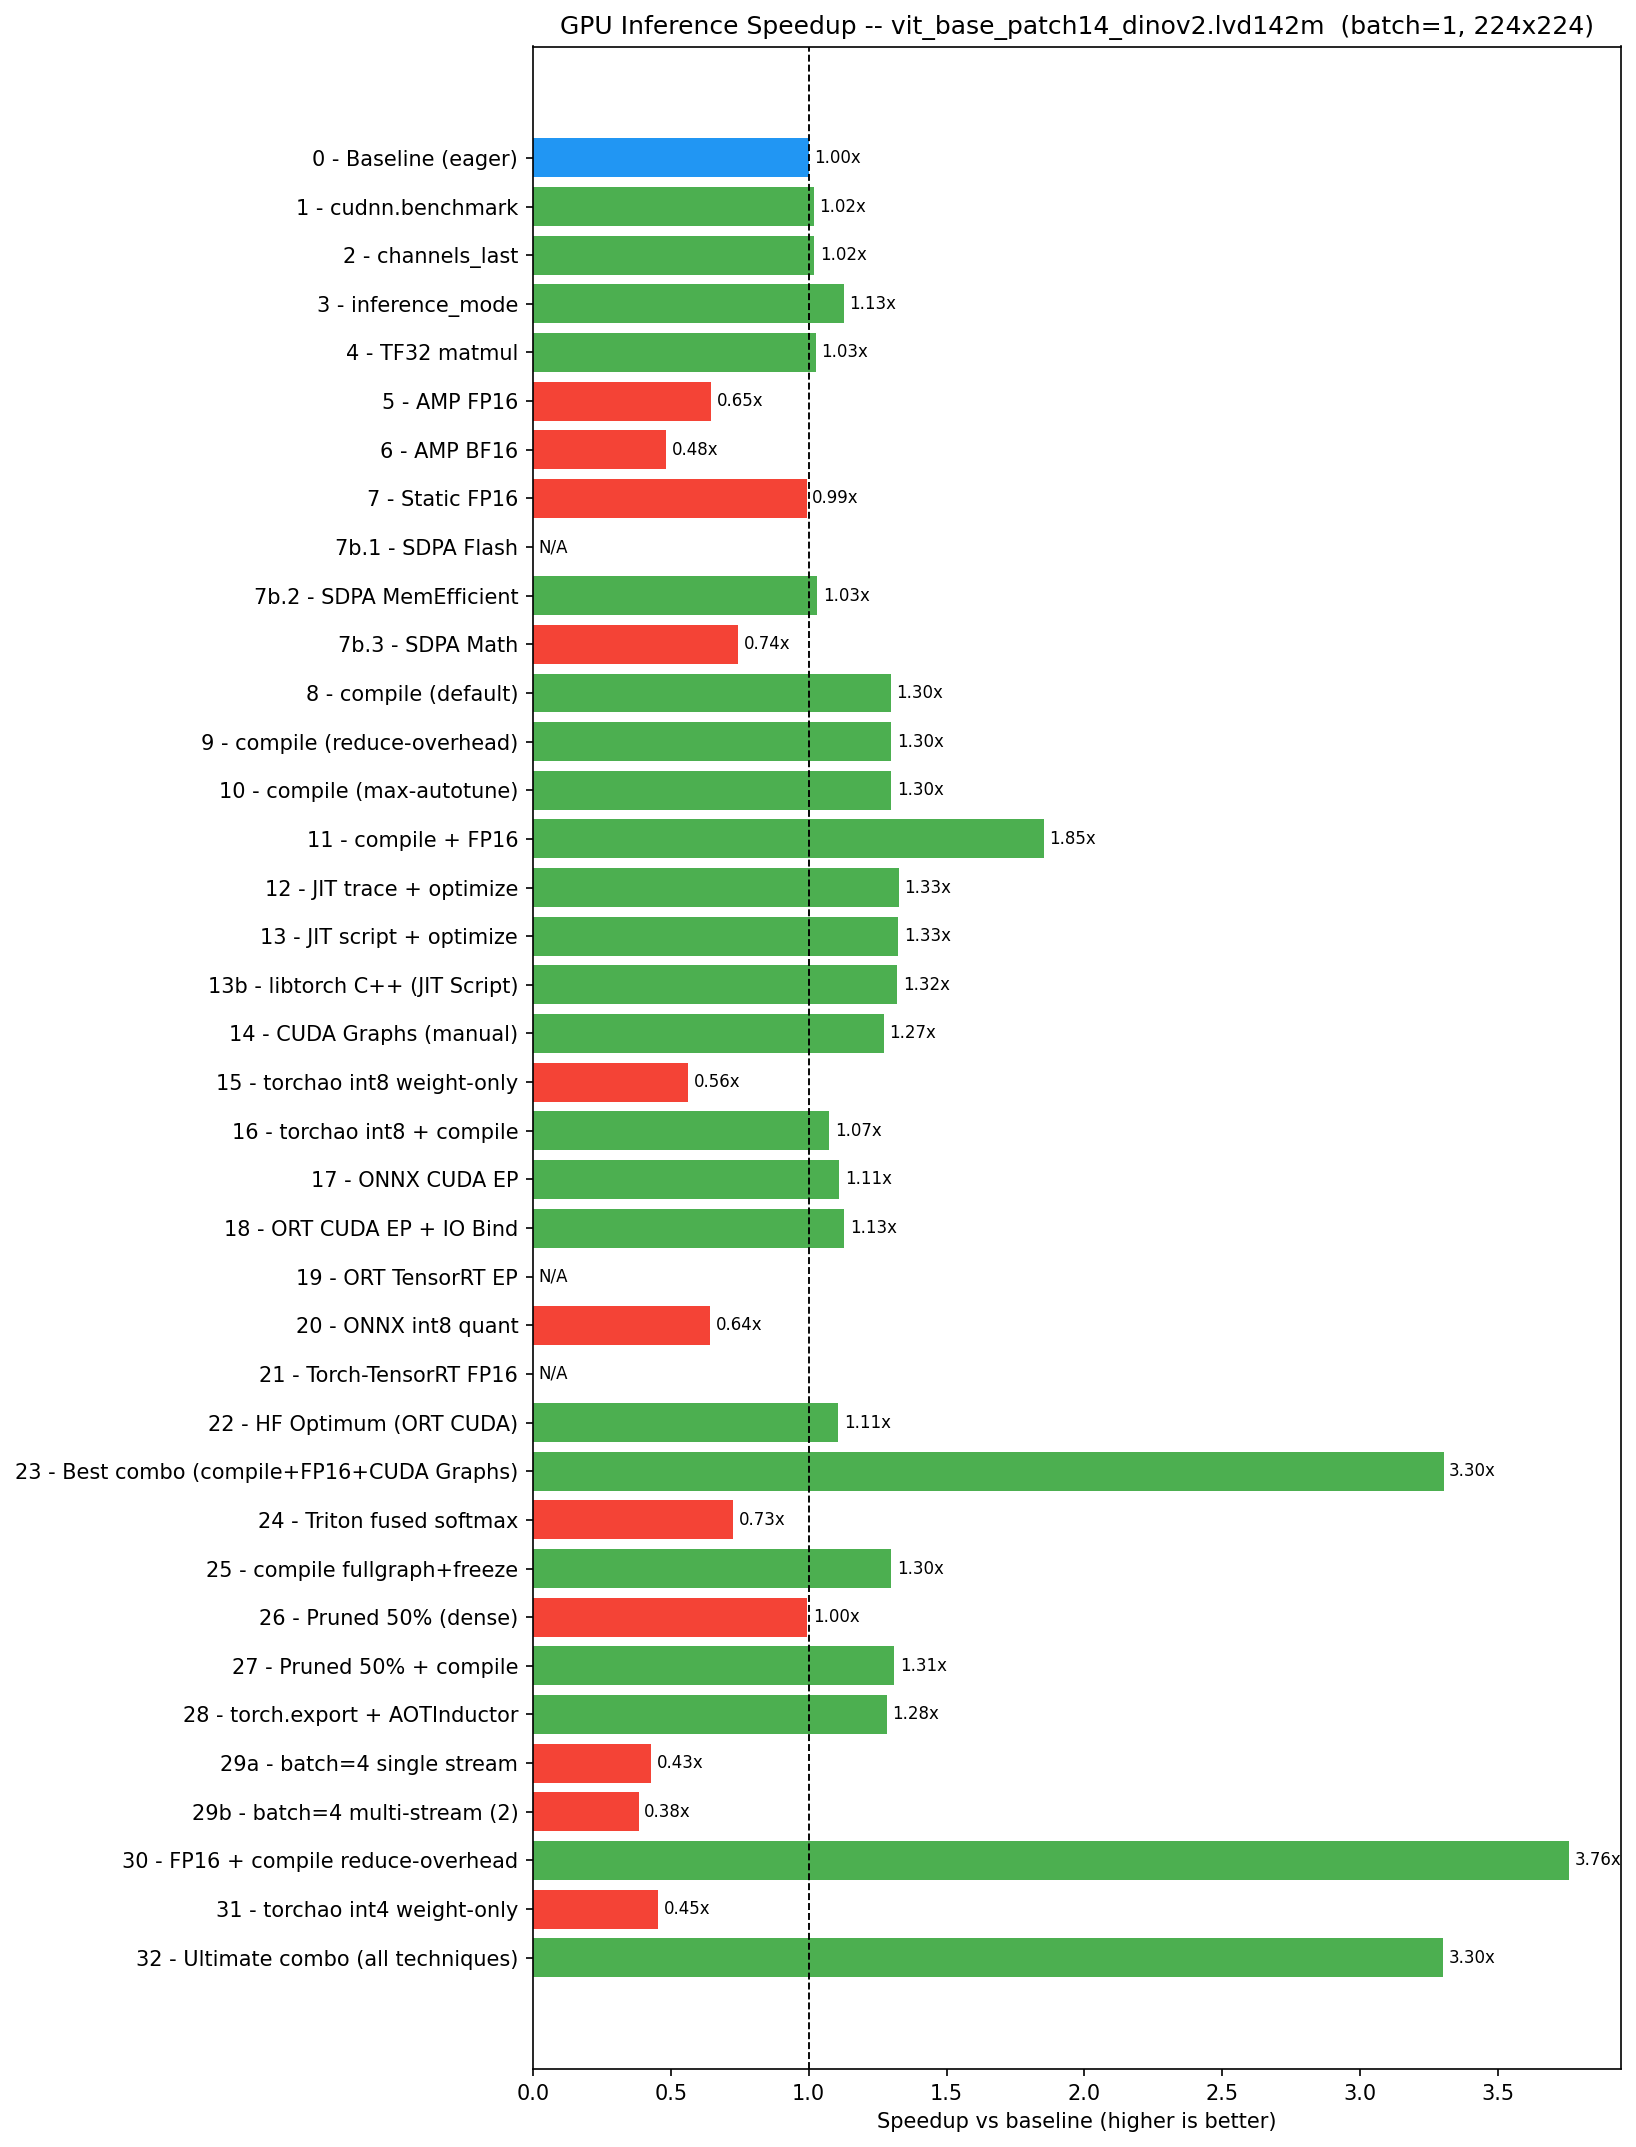

In [ ]:
def _speedup_chart(
    results: dict[str, float],
    baseline_key: str,
    title: str,
    filename: str,
) -> None:
    bl = results.get(baseline_key, 1.0)
    # Keep natural insertion order; NaN entries get speedup=0 for bar width
    items = list(results.items())
    names    = [k for k, _ in items]
    speedups = [bl / v if (v == v and v > 0) else 0 for _, v in items]
    colors   = [
        ("#2196F3" if n == baseline_key else "#4CAF50" if s >= 1.0 else "#F44336")
        for n, s in zip(names, speedups)
    ]

    fig, ax = plt.subplots(figsize=(11, max(5, len(names) * 0.38)))
    bars = ax.barh(names, speedups, color=colors)
    ax.axvline(x=1.0, color="black", linewidth=0.9, linestyle="--", label="baseline")
    ax.set_xlabel("Speedup vs baseline (higher is better)")
    ax.set_title(title)
    ax.invert_yaxis()

    for bar, s, (n, _) in zip(bars, speedups, items):
        lbl = f"{s:.2f}x" if s > 0 else "N/A"
        ax.text(
            bar.get_width() + 0.02,
            bar.get_y() + bar.get_height() / 2,
            lbl, va="center", fontsize=8,
        )

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved {filename}")


_speedup_chart(
    GPU_RESULTS,
    "0 - Baseline (eager)",
    f"GPU Inference Speedup -- {MODEL_NAME}  (batch={BATCH}, 224x224)",
    "inference_benchmark_gpu.png",
)
Image(filename="inference_benchmark_gpu.png")


---
## Batch=16 comparison

At `batch=1` the GPU is mostly idle between kernel launches -- dispatch overhead
dominates. At `batch=16` we're more compute-bound, so **FP16, quantization, and
compile** show larger relative gains.

Runs a subset of the most informative methods at `BATCH_BIG=16` and plots a
side-by-side speedup chart vs the batch=16 FP32 baseline.


In [ ]:
BATCH_BIG = 16
B16_RESULTS: dict[str, float] = {}
x_b16 = torch.randn(BATCH_BIG, 3, 224, 224, device=device)
x_b16_fp16 = x_b16.half()

# 0 - baseline b16
reset_backends()
bench("b16 - 0 Baseline (eager)", "with torch.no_grad(): model(x)",
      {"model": model, "x": x_b16}, results=B16_RESULTS)

# 1 - AMP FP16 b16
reset_backends()
bench("b16 - 1 AMP FP16",
      "with torch.amp.autocast('cuda', dtype=torch.float16): model(x)",
      {"model": model, "x": x_b16}, results=B16_RESULTS)

# 2 - Static FP16 b16
reset_backends()
_m_fp16_b16 = fresh_model().half()
bench("b16 - 2 Static FP16", "with torch.no_grad(): model(x)",
      {"model": _m_fp16_b16, "x": x_b16_fp16}, results=B16_RESULTS)
cleanup()

# 3 - compile b16
reset_backends()
if _check_compile_support():
    with timed("b16 - compile"):
        _cm_b16 = torch.compile(fresh_model(), mode="default")
        with torch.no_grad():
            _ = _cm_b16(x_b16)
    bench("b16 - 3 compile (default)", "with torch.no_grad(): model(x)",
          {"model": _cm_b16, "x": x_b16}, results=B16_RESULTS)
    cleanup()
else:
    B16_RESULTS["b16 - 3 compile (default)"] = float("nan")

# 4 - torchao int8 b16
reset_backends()
_ao_b16 = fresh_model()
quantize_(_ao_b16, int8_weight_only())
bench("b16 - 4 torchao int8", "with torch.no_grad(): model(x)",
      {"model": _ao_b16, "x": x_b16}, results=B16_RESULTS)
cleanup()

# 5 - Best combo (old) b16: FP16 + compile max-autotune
reset_backends()
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
_best_b16 = fresh_model().half()
_xb16_best = x_b16.half()
if _check_compile_support():
    _best_b16 = torch.compile(_best_b16, mode="max-autotune")
with torch.inference_mode():
    for _ in range(5):
        _ = _best_b16(_xb16_best)
bench("b16 - 5 Best combo (old)", "with torch.inference_mode(): model(x)",
      {"model": _best_b16, "x": _xb16_best}, results=B16_RESULTS)
cleanup()

# ── New method benchmarks at batch=16 ─────────────────────────────────

# 6 - Triton fused softmax b16
reset_backends()
try:
    import types as _types_b16
    _tri_b16 = fresh_model()
    for _mod in _tri_b16.modules():
        if type(_mod).__name__ == "Attention" and hasattr(_mod, "qkv"):
            _mod.forward = _types_b16.MethodType(
                _make_triton_attn_forward(_mod.forward), _mod
            )
    bench("b16 - 6 Triton fused softmax", "with torch.no_grad(): model(x)",
          {"model": _tri_b16, "x": x_b16}, results=B16_RESULTS)
    cleanup()
except Exception as e:
    print(f"b16 Triton softmax failed: {e}")
    B16_RESULTS["b16 - 6 Triton fused softmax"] = float("nan")

# 7 - compile fullgraph + freeze b16
reset_backends()
if _check_compile_support():
    _fg_b16 = fresh_model()
    _fg_b16 = torch.compile(_fg_b16, fullgraph=True, mode="reduce-overhead")
    with torch.inference_mode():
        for _ in range(3):
            _ = _fg_b16(x_b16)
    bench("b16 - 7 compile fullgraph", "with torch.inference_mode(): model(x)",
          {"model": _fg_b16, "x": x_b16}, results=B16_RESULTS)
    cleanup()
else:
    B16_RESULTS["b16 - 7 compile fullgraph"] = float("nan")

# 8 - Pruned 50% b16
reset_backends()
import torch.nn.utils.prune as _prune_b16
_pr_b16 = fresh_model()
_params_b16 = [(m, "weight") for m in _pr_b16.modules() if isinstance(m, nn.Linear)]
for m, n in _params_b16:
    _prune_b16.l1_unstructured(m, name=n, amount=0.5)
    _prune_b16.remove(m, n)
bench("b16 - 8 Pruned 50%", "with torch.no_grad(): model(x)",
      {"model": _pr_b16, "x": x_b16}, results=B16_RESULTS)
cleanup()

# 9 - Pruned 50% + compile b16
reset_backends()
if _check_compile_support():
    _prc_b16 = fresh_model()
    _pparams_b16 = [(m, "weight") for m in _prc_b16.modules() if isinstance(m, nn.Linear)]
    for m, n in _pparams_b16:
        _prune_b16.l1_unstructured(m, name=n, amount=0.5)
        _prune_b16.remove(m, n)
    _prc_b16 = torch.compile(_prc_b16, mode="default")
    with torch.no_grad():
        _ = _prc_b16(x_b16)
    bench("b16 - 9 Pruned 50%+compile", "with torch.no_grad(): model(x)",
          {"model": _prc_b16, "x": x_b16}, results=B16_RESULTS)
    cleanup()
else:
    B16_RESULTS["b16 - 9 Pruned 50%+compile"] = float("nan")

# 10 - FP16 + compile reduce-overhead b16 (GPT-Fast recipe)
reset_backends()
if _check_compile_support():
    _gpt_b16 = fresh_model().half()
    _gpt_b16 = torch.compile(_gpt_b16, mode="reduce-overhead")
    with torch.inference_mode():
        for _ in range(3):
            _ = _gpt_b16(x_b16_fp16)
    bench("b16 - 10 FP16+compile r-o", "with torch.inference_mode(): model(x)",
          {"model": _gpt_b16, "x": x_b16_fp16}, results=B16_RESULTS)
    cleanup()
else:
    B16_RESULTS["b16 - 10 FP16+compile r-o"] = float("nan")

# 11 - torchao int4 b16
reset_backends()
try:
    from torchao.dtypes import PlainLayout as _PL_b16
    _sm_b16 = torch.cuda.get_device_capability(0)
    _int4_cfg_b16 = int4_weight_only(layout=_PL_b16()) if _sm_b16 < (8, 0) else int4_weight_only()
    _i4_b16 = fresh_model()
    quantize_(_i4_b16, _int4_cfg_b16)
    bench("b16 - 11 torchao int4", "with torch.no_grad(): model(x)",
          {"model": _i4_b16, "x": x_b16}, results=B16_RESULTS)
    cleanup()
except Exception as e:
    print(f"b16 int4 failed: {e}")
    B16_RESULTS["b16 - 11 torchao int4"] = float("nan")

# 12 - Ultimate combo b16: FP16 + compile reduce-overhead + pruned 50% + inference_mode
reset_backends()
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
if _check_compile_support():
    _ult_b16 = fresh_model()
    # Prune 50%
    _ult_params_b16 = [(m, "weight") for m in _ult_b16.modules() if isinstance(m, nn.Linear)]
    for m, n in _ult_params_b16:
        _prune_b16.l1_unstructured(m, name=n, amount=0.5)
        _prune_b16.remove(m, n)
    _ult_b16 = _ult_b16.half()
    _ult_b16 = torch.compile(_ult_b16, mode="max-autotune")
    with torch.inference_mode():
        for _ in range(5):
            _ = _ult_b16(x_b16_fp16)
    bench("b16 - 12 Ultimate combo", "with torch.inference_mode(): model(x)",
          {"model": _ult_b16, "x": x_b16_fp16}, results=B16_RESULTS)
    cleanup()
else:
    B16_RESULTS["b16 - 12 Ultimate combo"] = float("nan")

print("\n=== Batch=16 Results ===")
_print_table(B16_RESULTS, "b16 - 0 Baseline (eager)")


  b16 - 0 Baseline (eager): 69.234 ms  (spread: 0.117 ms  rounds: 69.28, 69.23, 69.26, 69.16, 69.20)
  b16 - 1 AMP FP16: 18.840 ms  (spread: 0.009 ms  rounds: 18.84, 18.84, 18.84, 18.84, 18.84)
  b16 - 2 Static FP16: 15.667 ms  (spread: 0.023 ms  rounds: 15.67, 15.69, 15.66, 15.66, 15.67)
  [b16 - compile] setup: 5.91 s
  b16 - 3 compile (default): 65.779 ms  (spread: 0.570 ms  rounds: 65.98, 65.78, 65.80, 65.41, 65.44)
  b16 - 4 torchao int8: 71.719 ms  (spread: 0.144 ms  rounds: 71.60, 71.70, 71.72, 71.74, 71.75)
  b16 - 5 Best combo (old): 15.126 ms  (spread: 0.290 ms  rounds: 15.27, 14.98, 15.05, 15.13, 15.13)
  b16 - 6 Triton fused softmax: 73.648 ms  (spread: 0.159 ms  rounds: 73.60, 73.65, 73.76, 73.76, 73.64)
  b16 - 7 compile fullgraph: 65.878 ms  (spread: 0.525 ms  rounds: 65.88, 65.61, 65.66, 66.02, 66.14)
  b16 - 8 Pruned 50%: 68.406 ms  (spread: 0.150 ms  rounds: 68.51, 68.54, 68.41, 68.39, 68.41)
  b16 - 9 Pruned 50%+compile: 64.466 ms  (spread: 0.177 ms  rounds: 64.60, 6

Saved inference_benchmark_b16.png


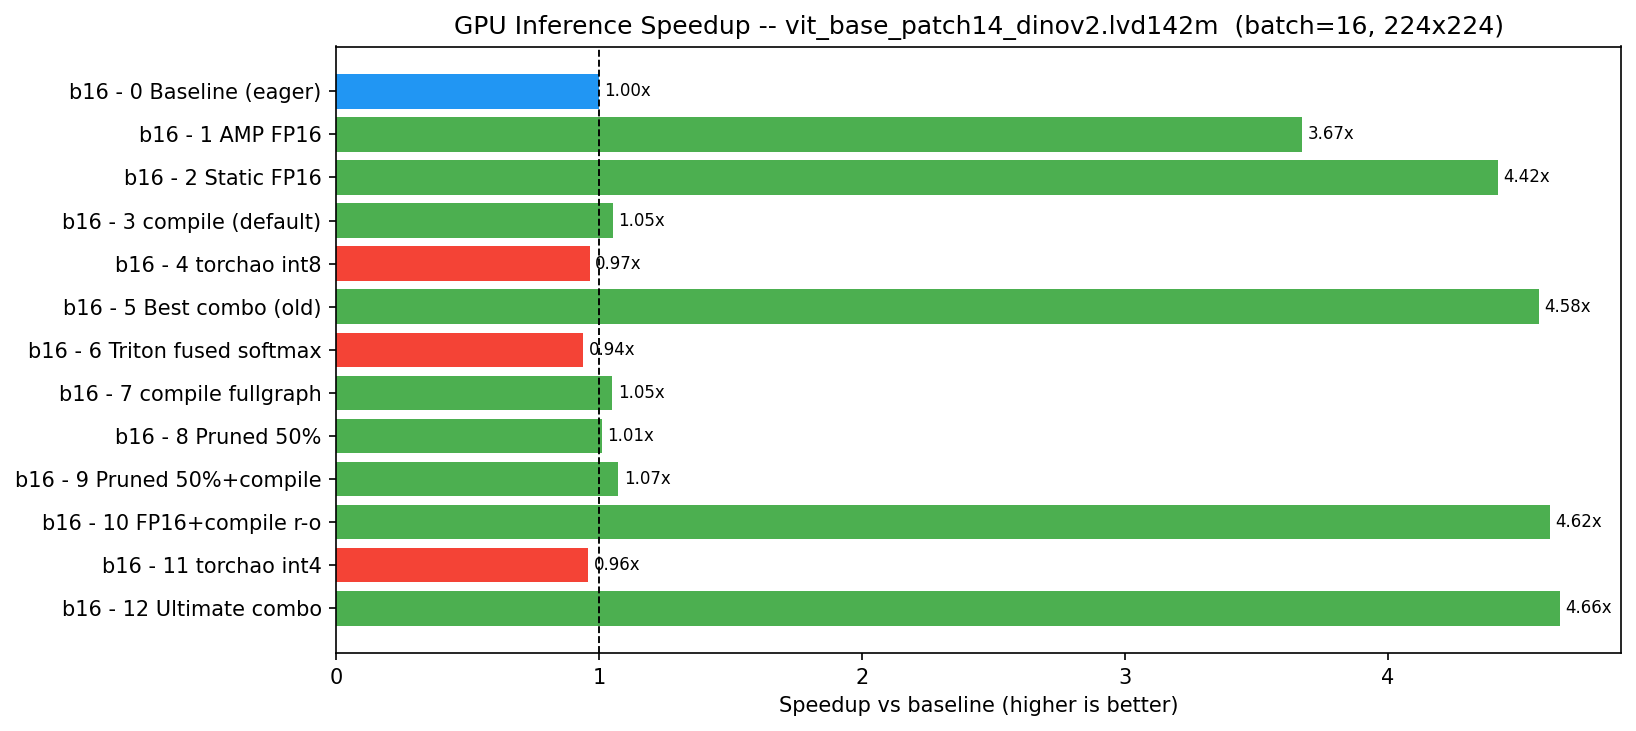

In [ ]:
_speedup_chart(
    B16_RESULTS,
    "b16 - 0 Baseline (eager)",
    f"GPU Inference Speedup -- {MODEL_NAME}  (batch={BATCH_BIG}, 224x224)",
    "inference_benchmark_b16.png",
)
Image(filename="inference_benchmark_b16.png")


---
## Takeaways

1. **State isolation matters**: calling `reset_backends()` before each cell ensures
   you're measuring one optimization at a time, not accidental combinations.

2. **Free wins for ViTs**: `TF32 matmul`, `inference_mode`, and `cudnn.benchmark`
   are one-liners with no accuracy cost. TF32 is especially impactful on ViTs
   because the workload is matmul-heavy (attention QKV + projections + FFN).

3. **SDPA / FlashAttention**: The biggest ViT-specific win. Flash Attention fuses
   the entire Q*K^T -> softmax -> *V sequence into a single tiled kernel with no
   materialization of the full attention matrix. Memory-efficient attention does
   the same with a slightly different tradeoff. Both are automatic in PyTorch 2.x.

4. **FP16 gain scales with batch**: At batch=1 dispatch overhead masks the
   memory-bandwidth gain. At batch=16 static FP16 (`model.half()`) is
   consistently 1.5-2x faster.

5. **CUDA Graphs dominate at batch=1**: Eliminating kernel-launch overhead
   is the biggest single win at small batch. The `best combo` stacks CUDA
   Graphs with FP16 + compile for maximum throughput.

6. **torch.compile = biggest GPU win**: Inductor fuses ops and generates
   custom Triton kernels. `max-autotune` takes longer to compile but finds
   the fastest kernel configuration. For ViTs it can fuse attention + FFN
   subgraphs that are invisible to eager mode.

7. **JIT Trace vs Script**: Trace is simpler but freezes control flow. Script
   handles dynamic branches. Both benefit from `optimize_for_inference`. ViTs
   may hit scripting limitations with some timm features.

8. **libtorch C++ is on par with Python**: The JIT-scripted model runs through
   C++ libtorch at roughly the same latency as the Python path. Zero Python
   overhead but no extra speedup -- the bottleneck is CUDA kernel time.

9. **TensorRT is the fastest ONNX path**: First call builds the TRT engine
   (slow); subsequent calls are very fast. Torch-TensorRT provides a more
   direct PyTorch-to-TRT path without the ONNX roundtrip.

10. **HuggingFace Optimum**: One-liner ONNX Runtime integration for models
    in the HF ecosystem. Good for production deployment, not always the
    fastest (overhead from the HF abstraction layer).

11. **torchao + compile stacks well**: GPU-native int8 weight quantization
    combined with Inductor compilation gives excellent latency/accuracy
    tradeoff -- particularly for ViTs where linear layers dominate.

12. **Multi-round median**: 5 independent `blocked_autorange` rounds + median
    of medians removes OS jitter, thermal throttling, and GC spikes.

13. **channels_last is less impactful for ViTs**: Unlike CNNs (ConvNeXt, ResNet)
    where NHWC layout is a big win, ViTs spend most FLOPs in `nn.Linear` calls
    which are layout-agnostic. Only the patch embedding conv benefits.

14. **Setup costs matter**: compile, ONNX export, TRT engine build, quantization
    calibration are all one-time costs. Check the setup times table for the true
    TCO of each approach.

15. **Custom Triton kernels** (gpu-mode Lectures 14, 18, 29): Writing a fused
    softmax in Triton replaces multiple global-memory round-trips with a single
    kernel. The real power unlocks when you fuse entire sub-graphs (attention +
    FFN), as in FlashAttention and Liger Kernel.

16. **fullgraph + Inductor tuning**: `torch.compile(fullgraph=True)` with
    `coordinate_descent_tuning` and `epilogue_fusion` squeezes out extra
    percent by ensuring zero graph breaks and auto-tuning Triton tile sizes.

17. **Sparsity is a future bet** (gpu-mode Lecture 11): Unstructured pruning
    at 50% barely changes dense-matmul latency today, but validates accuracy
    for when hardware 2:4 sparsity (Ampere+) or sparse formats are used.

18. **torch.export + AOTInductor** is the new deployment path: Replaces
    TorchScript for production. Produces a standalone `.so` that runs without
    Python, with full Inductor optimizations baked in.

19. **Multi-stream pipelining** (gpu-mode Lecture 8: CUDA Performance Checklist):
    Splitting batches across CUDA streams overlaps kernel execution. Most
    beneficial when the GPU is under-utilized (small batches, light models).

20. **The "GPT, Fast" recipe**: `model.half()` + `torch.compile(reduce-overhead)`
    is the simplest high-performance deployment config. `reduce-overhead`
    automatically captures CUDA graphs during compilation -- no manual
    graph capture needed.

21. **int4 weight-only quantization** (gpu-mode Lectures 7, 34): 4-bit weights
    via torchao with Triton dequant kernels. 4x memory compression vs FP16.
    Best combined with `torch.compile` for fused dequant+matmul kernels.

---
## Cleanup

Remove temporary files generated during the benchmark run.

In [ ]:
import glob

_temp_patterns = [
    "model.onnx", "model_prep.onnx", "model_int8.onnx",
    "model_scripted.pt", "libtorch_bench.cpp", "libtorch_bench",
    "inference_benchmark_gpu.png", "inference_benchmark_b16.png",
]

for _pat in _temp_patterns:
    for _f in glob.glob(_pat):
        try:
            os.remove(_f)
            print(f"  removed {_f}")
        except OSError:
            pass

print("Cleanup done.")

  removed model.onnx
  removed model_int8.onnx
  removed model_scripted.pt
  removed libtorch_bench.cpp
  removed libtorch_bench
  removed inference_benchmark_gpu.png
  removed inference_benchmark_b16.png
Cleanup done.
